# De-Mean NEMSIS Data and Explore Relationship with WaPo+Twitter

In [1]:
import pandas as pd
import numpy as np
from numpy.polynomial.polynomial import polyfit
import matplotlib.pyplot as plt
import seaborn as sn
import matplotlib.dates as mdates
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
import matplotlib.cm as cm
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_selection import f_regression
from statsmodels.stats.anova import anova_lm


ModuleNotFoundError: No module named 'statsmodels'

In [2]:
db_path = "C:/Users/meita/Dropbox (MIT)/NEMSIS Data/"

In [3]:
nemsis = pd.read_csv(db_path + "Data/NEMSIS/Pre-processed/count_nemsis.csv")
twitter = pd.read_csv(db_path + "Data/Tweets/Pre-processed/tweet_count_w_info.csv")
wapo = pd.read_csv(db_path + "Data/WaPo/Pre-processed/fatal-police-shootings-CLEANED.csv")

# count data

In [225]:
len(np.unique(urban_private_dd['CensusDivision']))

9

In [221]:
np.sum(nemsis['total'])

26478020

In [224]:
np.sum(urban_private_dd['all_calls'])

10854562

# Aggregate and Filter Data

In [4]:
#get the nemsis data at the division day level for urban + private and urban +street/public

#nemsis - division/day/ - urban - public
urban = nemsis[nemsis['urban'] == 'urban']

urban_private = urban[urban['origin'] == 'private']
urban_street = urban[urban['origin'].isin(['public', 'street'])]

#now group by division and day
urban_private_dd = pd.DataFrame(urban_private.groupby(['day', 'CensusDivision']).sum()['total'])
urban_street_dd = pd.DataFrame(urban_street.groupby(['day', 'CensusDivision']).sum()['total'])

#now just get the mental health calls
urban_private_mh = pd.DataFrame(urban_private[urban_private['psych']])
urban_street_mh = pd.DataFrame(urban_street[urban_street['psych']])

#group the mental health by division and day
urban_private_dd_mh = pd.DataFrame(urban_private_mh.groupby(['day', 'CensusDivision']).sum()['total'])
urban_street_dd_mh = pd.DataFrame(urban_street_mh.groupby(['day', 'CensusDivision']).sum()['total'])

In [5]:
#now get the percentage of mental health related calls
urban_private_dd.columns = ['all_calls']
urban_street_dd.columns = ['all_calls']
urban_private_dd_mh.columns = ['mh_calls']
urban_street_dd_mh.columns = ['mh_calls']

In [6]:
urban_private_dd = urban_private_dd.join(urban_private_dd_mh)
urban_street_dd = urban_street_dd.join(urban_street_dd_mh)

In [7]:
urban_private_dd['perc_mh'] = np.divide(urban_private_dd['mh_calls'],urban_private_dd['all_calls'])
urban_street_dd['perc_mh'] = np.divide(urban_street_dd['mh_calls'], urban_private_dd['all_calls'])

In [8]:
urban_private_dd = urban_private_dd.reset_index()
urban_street_dd = urban_street_dd.reset_index()

In [9]:
urban_private_dd['day'] = pd.to_datetime(urban_private_dd.day)
urban_street_dd['day'] = pd.to_datetime(urban_street_dd.day)

In [10]:
#now get the day of the week for each day
urban_private_dd['weekday'] = urban_private_dd.day.dt.strftime('%A')
urban_street_dd['weekday'] = urban_street_dd.day.dt.strftime('%A')

In [11]:
urban_private_dd.groupby(['CensusDivision', 'weekday']).mean()['perc_mh']

CensusDivision      weekday  
East North Central  Friday       0.044189
                    Monday       0.044569
                    Saturday     0.043413
                    Sunday       0.045897
                    Thursday     0.044642
                                   ...   
West South Central  Saturday     0.030239
                    Sunday       0.031106
                    Thursday     0.030584
                    Tuesday      0.032149
                    Wednesday    0.031489
Name: perc_mh, Length: 63, dtype: float64

# De-Mean data by day of the week for each Division

In [12]:
urban_private_mean = pd.DataFrame(urban_private_dd.groupby(['CensusDivision', 'weekday']).mean()['perc_mh'])
urban_street_mean = pd.DataFrame(urban_street_dd.groupby(['CensusDivision', 'weekday']).mean()['perc_mh'])

In [13]:
#create a function to demean each row
def demean_df(row, mean):
    day = row['weekday']
    raw = row['perc_mh']
    div = row['CensusDivision']
    daily_mean = mean.loc[div, day]['perc_mh']
#     print(daily_mean)
#     print(raw - daily_mean)
    return raw - daily_mean

In [14]:
urban_private_dd['dm_perc_mh'] = urban_private_dd.apply(demean_df, mean = urban_private_mean, axis = 1)
urban_street_dd['dm_perc_mh'] = urban_street_dd.apply(demean_df, mean = urban_street_mean, axis = 1)

In [15]:
urban_private_dd

,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh
0,2019-01-01,East North Central,3042,138,0.045365,Tuesday,-0.001239
1,2019-01-01,East South Central,1397,47,0.033644,Tuesday,-0.001614
2,2019-01-01,Middle Atlantic,3482,138,0.039632,Tuesday,-0.001653
3,2019-01-01,Mountain,2489,102,0.040980,Tuesday,0.003609
4,2019-01-01,New England,926,68,0.073434,Tuesday,0.016626
...,...,...,...,...,...,...,...
3280,2019-12-31,New England,1331,69,0.051841,Tuesday,-0.004967
3281,2019-12-31,Pacific,1754,52,0.029647,Tuesday,0.008184
3282,2019-12-31,South Atlantic,8147,204,0.025040,Tuesday,-0.001988
3283,2019-12-31,West North Central,1373,53,0.038602,Tuesday,-0.005262


## Graph the Demeaned Calls by Region and Day

In [158]:
def graph_daily_calls(df, col_to_graph, title):
    plt.plot(df['day'], df[col_to_graph])
    plt.title(title)
    plt.show()

In [159]:
def graph_intervals(df, col_to_graph, title):
    
    minor_ticks_top=df[col_to_graph]
    plt.plot(df['day'], df[col_to_graph])
    plt.title(title)

    
    plt.set_xticks(df[col_to_graph])
    plt.set_yticks(df[col_to_graph])
    plt.fill_between(df[col_to_graph])
    
#     axes.set_xticks(df[col_to_graph])
#     axes.set_yticks(df[col_to_graph])
#     axes.fill_between(df[col_to_graph])
#     axes.set_xticks(minor_ticks_top,minor=True)
#     axes.set_yticks(minor_ticks_top,minor=True)
    plt.set_title(title)
    plt.grid(which="major",alpha=0.6)
    plt.grid(which="minor",alpha=0.3)

    plt.tight_layout()
    plt.hist(df[q_cut])
    plt.show()


In [160]:
def graph_tweets(df, col_to_graph):
    plt.plot(df['day'], df[col_to_graph], label =col_to_graph)
    plt.legend()

In [19]:
div_grouped_private = urban_private_dd.groupby(['CensusDivision'])
# print(urban_private_dd['CensusDivision'])
total_groups = len(np.unique(urban_private_dd['CensusDivision']))
for name, group in div_grouped_private:
    group['q_cut_mh'] = pd.qcut(group['dm_perc_mh'], 5)    
    w_tweets = group.merge(tweets_by_day, on = 'day')
#     print(w_tweets.groupby(['q_cut_mh']).mean()['all_retweets'])
#     interm  = pd.DataFrame(w_tweets.groupby(['q_cut_mh']).mean()['all_retweets']).rename(columns = {'all_retweets':name})
#     tweet_sum = tweet_sum.merge(interm, right_index = True, left_index = True)
#     display(interm)
    
    graph_daily_calls(pd.DataFrame(group), 'dm_perc_mh', name+ ' De-Meaned Share of MH Calls and Tweets')
    graph_intervals(pd.DataFrame(group), 'dm_perc_mh', name+ ' De-Meaned Share of MH Calls and Tweets')
    graph_tweets(pd.DataFrame(group), 'all_retweets')
    plt.show()
    plt.close('all')
    

NameError: name 'graph_daily_calls' is not defined

# Group and Aggregate Tweets

In [16]:
tweets_by_day = pd.DataFrame(twitter.groupby(['date']).sum())[['tweet_count', 'retweet_count', 'quote_count']]
tweets_by_day['all_retweets'] = tweets_by_day['retweet_count'] + tweets_by_day['quote_count']

In [17]:
tweets_by_day['day'] = pd.to_datetime(tweets_by_day.index)

In [164]:
#lets now split the tweet days into quantiles
labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
q_cut_tweets, bins= pd.qcut(tweets_by_day['all_retweets'], 5, labels, retbins = True)

In [165]:
q_cut_tweets['day'] = pd.to_datetime(q_cut_tweets.index)

In [166]:
q_cut_tweets

,all_retweets,day
date,,
2019-01-01,0-20,2019-01-01
2019-01-02,40-60,2019-01-02
2019-01-03,40-60,2019-01-03
2019-01-04,40-60,2019-01-04
2019-01-05,20-40,2019-01-05
...,...,...
2019-12-27,0-20,2019-12-27
2019-12-28,60-80,2019-12-28
2019-12-29,60-80,2019-12-29


In [167]:
#lets get the quantiles of the mental health related 911 calls for each division
results = pd.DataFrame(index = labels)
for name, group in div_grouped_private:
    #join with the tweets information
    w_quant = group.merge(q_cut_tweets, on = 'day')
    interm  = pd.DataFrame(w_quant.groupby(['all_retweets']).mean()['dm_perc_mh']).rename(columns = {'dm_perc_mh':name})
    results = results.merge(interm, right_index = True, left_index = True)

In [168]:
results.transpose()

,0-20,20-40,40-60,60-80,80-100
East North Central,-0.000531,0.000272,-0.000157,-0.000029,0.000445
East South Central,-0.002065,-0.000373,0.001256,0.001123,0.000059
Middle Atlantic,-0.001244,0.000088,0.000753,0.000446,-0.000044
Mountain,-0.001385,0.000036,0.000142,0.000760,0.000447
New England,0.000377,-0.000458,-0.000556,0.000331,0.000306
Pacific,-0.000047,0.000366,-0.000242,0.000025,-0.000103
South Atlantic,-0.000261,-0.000183,0.000135,0.000029,0.000280
West North Central,-0.000529,0.000011,0.000829,0.000828,-0.001140
West South Central,-0.000369,-0.000305,0.000954,-0.000005,-0.000275


# Lets do the opposite and get the quantiles of mental Health Related calls

In [49]:
twitter['day'] = pd.to_datetime(twitter['date'])

In [81]:
twitter['all_retweets'] = twitter['retweet_count'] + twitter['quote_count']

In [59]:
'''
define a function to get the percent of tweets about a black person on a set of days
'''
def perc_black(days):
    days = pd.to_datetime(days)
    tweets = twitter[twitter['day'].isin(days)]
#     print(tweets)
    total = tweets.shape[0]
    black = tweets[tweets['race'] == 'B'].shape[0]
    return black/total

In [78]:
'''
define a function to get the percent of RETWEETS about a black person on a set of days
'''
def perc_retweets_black(days):
    days = pd.to_datetime(days)
    tweets = twitter[twitter['day'].isin(days)]
#     print(tweets)
#     tweets['all_retweets'] = tweets['retweet_count'] + tweets['quote_count']
    total = np.sum(tweets['all_retweets'])
    black = np.sum(tweets[tweets['race'] == 'B']['all_retweets'])
    return black/total

In [56]:
'''
define function to get the percent of tweets about a mentally ill person on a set of days
'''
def perc_mh(days):
    days = pd.to_datetime(days)
    tweets = twitter[twitter['day'].isin(days)]
#     print(tweets)
    total = tweets.shape[0]
    mh = tweets[tweets['signs_of_mental_illness'] == True].shape[0]
    return mh/total

In [79]:
'''
define a function to get the percent of RETWEETS about a mentally ill person on a set of days
'''
def perc_retweets_mh(days):
    days = pd.to_datetime(days)
    tweets = twitter[twitter['day'].isin(days)]
#     print(tweets)
#     tweets['all_retweets'] = tweets['retweet_count'] + tweets['quote_count']
    total = np.sum(tweets['all_retweets'])
    mh = np.sum(tweets[tweets['signs_of_mental_illness'] == True]['all_retweets'])
    return mh/total

In [70]:
perc_retweets_mh(['2019-01-01', '2019-05-10'])

<ipython-input-69-8bb1187d5e86>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tweets['all_retweets'] = tweets['retweet_count'] + tweets['quote_count']


0.1440677966101695

In [83]:
#lets do it by region
# tweet_sum = pd.DataFrame(index = )

for name, group in div_grouped_private:
    group['q_cut_mh'] = pd.qcut(group['dm_perc_mh'], 5)
#     print(tweets_by_day)
    
    w_tweets = group.merge(tweets_by_day, on = 'day')
#     print(w_tweets.groupby(['q_cut_mh']).mean())
#     print(w_tweets)
    print(name)
    cut = w_tweets.groupby(['q_cut_mh'])
    
    black_tweets = []
    mh_tweets = []
    black_retweets = []
    mh_retweets = []
    
    for cat, df in cut:
#         print(df)
        black_tweets.append(perc_black(df['day']))
        mh_tweets.append(perc_mh(df['day']))
        black_retweets.append(perc_retweets_black(df['day']))
        mh_retweets.append(perc_retweets_mh(df['day']))
        
    interm  = pd.DataFrame(cut.mean())[['tweet_count', 'all_retweets']]
    interm['perc_black_tweets'] = black_tweets
    interm['perc_black_retweets'] = black_retweets
    interm['perc_mh_tweets'] = mh_tweets
    interm['perc_mh_retweets'] = mh_retweets
#     tweet_sum = tweet_sum.merge(interm, right_index = True, left_index = True)
    display(interm)


East North Central


,tweet_count,all_retweets,perc_black_tweets,perc_black_retweets,perc_mh_tweets,perc_mh_retweets
q_cut_mh,,,,,,
"(-0.012400000000000001, -0.00373]",90.630137,765.479452,0.559197,0.763905,0.193446,0.041535
"(-0.00373, -0.00131]",121.712329,883.506849,0.580808,0.726107,0.189899,0.217176
"(-0.00131, 0.000817]",88.945205,1057.424658,0.560000,0.726850,0.193171,0.218067
"(0.000817, 0.00369]",174.356164,2213.904110,0.575610,0.939381,0.220488,0.024280
"(0.00369, 0.0201]",77.109589,424.246575,0.557360,0.831579,0.232487,0.126639


East South Central


,tweet_count,all_retweets,perc_black_tweets,perc_black_retweets,perc_mh_tweets,perc_mh_retweets
q_cut_mh,,,,,,
"(-0.0142, -0.00451]",165.356164,1282.191781,0.534115,0.861068,0.207889,0.135491
"(-0.00451, -0.00191]",95.575342,1074.876712,0.581874,0.874200,0.208033,0.034983
"(-0.00191, 0.00103]",101.054795,1324.369863,0.578947,0.875340,0.193957,0.075725
"(0.00103, 0.00471]",99.684932,1195.027397,0.579256,0.757672,0.207436,0.131252
"(0.00471, 0.0185]",91.082192,468.095890,0.557199,0.681338,0.213018,0.199263


Middle Atlantic


...

,tweet_count,all_retweets,perc_black_tweets,perc_black_retweets,perc_mh_tweets,perc_mh_retweets
q_cut_mh,,,,,,
"(-0.00741, -0.00171]",115.643836,682.246575,0.588608,0.844330,0.209916,0.056100
"(-0.00171, -0.000483]",104.000000,1829.876712,0.574129,0.841010,0.194030,0.127675
"(-0.000483, 0.000541]",64.917808,394.095890,0.569336,0.806006,0.215820,0.081894
"(0.000541, 0.00181]",165.082192,1727.520548,0.539448,0.875227,0.188363,0.099509
"(0.00181, 0.00596]",103.109589,710.821918,0.563265,0.679148,0.222449,0.120505


West North Central


,tweet_count,all_retweets,perc_black_tweets,perc_black_retweets,perc_mh_tweets,perc_mh_retweets
q_cut_mh,,,,,,
"(-0.0217, -0.00656]",167.027397,1923.287671,0.550866,0.835057,0.214286,0.162956
"(-0.00656, -0.00228]",133.246575,1029.000000,0.582031,0.887815,0.216797,0.060665
"(-0.00228, 0.00186]",83.123288,919.767123,0.556444,0.845345,0.208791,0.125761
"(0.00186, 0.00629]",65.876712,330.424658,0.567433,0.567389,0.207792,0.146180
"(0.00629, 0.0234]",103.479452,1142.082192,0.574927,0.825457,0.183154,0.019203


West South Central


,tweet_count,all_retweets,perc_black_tweets,perc_black_retweets,perc_mh_tweets,perc_mh_retweets
q_cut_mh,,,,,,
"(-0.01039, -0.0028]",87.328767,1300.506849,0.592350,0.836302,0.197814,0.043165
"(-0.0028, -0.000837]",120.931507,832.780822,0.569034,0.776175,0.205128,0.223216
"(-0.000837, 0.000832]",137.506849,2256.301370,0.556317,0.860251,0.206660,0.103291
"(0.000832, 0.00281]",127.575342,618.986301,0.555775,0.834551,0.212241,0.062962
"(0.00281, 0.00887]",79.410959,335.986301,0.562500,0.701798,0.207341,0.141925


# Look at Lag Tweets/MH Calls

In [170]:
urban_private_dd

,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh
0,2019-01-01,East North Central,3042,138,0.045365,Tuesday,-0.001239
1,2019-01-01,East South Central,1397,47,0.033644,Tuesday,-0.001614
2,2019-01-01,Middle Atlantic,3482,138,0.039632,Tuesday,-0.001653
3,2019-01-01,Mountain,2489,102,0.040980,Tuesday,0.003609
4,2019-01-01,New England,926,68,0.073434,Tuesday,0.016626
...,...,...,...,...,...,...,...
3280,2019-12-31,New England,1331,69,0.051841,Tuesday,-0.004967
3281,2019-12-31,Pacific,1754,52,0.029647,Tuesday,0.008184
3282,2019-12-31,South Atlantic,8147,204,0.025040,Tuesday,-0.001988
3283,2019-12-31,West North Central,1373,53,0.038602,Tuesday,-0.005262


In [171]:
q_cut_tweets_no_labels['day'] = pd.to_datetime(q_cut_tweets_no_labels.index)

In [172]:
#lets look at the tweets in the top quantile:
#by the entire thing
q_cut_tweets_no_labels
w_day_of = q_cut_tweets.merge(urban_private_dd, how = 'right', on ='day')

In [173]:
w_day_of

,all_retweets,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh
0,0-20,2019-01-01,East North Central,3042,138,0.045365,Tuesday,-0.001239
1,0-20,2019-01-01,East South Central,1397,47,0.033644,Tuesday,-0.001614
2,0-20,2019-01-01,Middle Atlantic,3482,138,0.039632,Tuesday,-0.001653
3,0-20,2019-01-01,Mountain,2489,102,0.040980,Tuesday,0.003609
4,0-20,2019-01-01,New England,926,68,0.073434,Tuesday,0.016626
...,...,...,...,...,...,...,...,...
3280,40-60,2019-12-31,New England,1331,69,0.051841,Tuesday,-0.004967
3281,40-60,2019-12-31,Pacific,1754,52,0.029647,Tuesday,0.008184
3282,40-60,2019-12-31,South Atlantic,8147,204,0.025040,Tuesday,-0.001988
3283,40-60,2019-12-31,West North Central,1373,53,0.038602,Tuesday,-0.005262


In [174]:
grouped_by_div = w_day_of.groupby(['CensusDivision'])

In [175]:
result = pd.DataFrame(columns = w_day_of.columns)
for name, group in grouped_by_div:
#     print(group)
    for i in range(1,8):
        group['next_'+str(i)] = group['dm_perc_mh'].shift(-i)
    result = pd.concat([result, group])
    
# past 7 days of what ? Demeaned? by census div or no?
#

In [176]:
result = result.merge(tweets_by_day[['day', 'all_retweets']], on = 'day', how = 'left')

In [178]:
#run some regressions and see what we find
top_10 = result[result['all_retweets_x'] == '80-100']

In [180]:
result_grouped = result.groupby(['CensusDivision'])
for name, group in result_grouped:
#     print(group.columns)
    display(group.sort_values(by = 'all_retweets_y', ascending = False)[:10])
#     for c 

,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
285,80-100,2019-10-13,East North Central,2783,135,0.048509,Sunday,0.002612,-0.002031,0.003292,0.002057,0.005246,-0.002181,0.003514,0.005036,57720
60,80-100,2019-03-02,East North Central,2599,113,0.043478,Saturday,0.000065,-0.011013,0.001991,0.003721,0.003188,0.003615,-0.005885,0.003583,42666
287,80-100,2019-10-15,East North Central,2866,143,0.049895,Tuesday,0.003292,0.002057,0.005246,-0.002181,0.003514,0.005036,-0.000662,0.003233,38157
133,80-100,2019-05-14,East North Central,2819,137,0.048599,Tuesday,0.001995,-0.000958,-0.003463,0.000065,-0.001190,0.000089,0.010133,0.000709,27113
286,80-100,2019-10-14,East North Central,2868,122,0.042538,Monday,-0.002031,0.003292,0.002057,0.005246,-0.002181,0.003514,0.005036,-0.000662,22062
61,80-100,2019-03-03,East North Central,2666,93,0.034884,Sunday,-0.011013,0.001991,0.003721,0.003188,0.003615,-0.005885,0.003583,-0.006249,14044
313,80-100,2019-11-10,East North Central,2762,115,0.041636,Sunday,-0.004260,-0.007545,-0.005938,-0.005189,0.002942,-0.001586,0.003134,0.004103,10765
284,80-100,2019-10-12,East North Central,2756,104,0.037736,Saturday,-0.005677,0.002612,-0.002031,0.003292,0.002057,0.005246,-0.002181,0.003514,10470
217,80-100,2019-08-06,East North Central,2864,127,0.044344,Tuesday,-0.002260,0.000422,0.005340,0.004957,0.002572,-0.002082,0.005351,-0.002939,9932
194,80-100,2019-07-14,East North Central,2846,127,0.044624,Sunday,-0.001273,0.001443,0.001659,-0.000843,0.000879,-0.001337,-0.001096,-0.003663,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
650,80-100,2019-10-13,East South Central,1706,60,0.035170,Sunday,0.000963,-0.007172,-0.007735,0.000580,-0.007020,0.003759,-0.004041,-0.005296,57720
425,80-100,2019-03-02,East South Central,1154,33,0.028596,Saturday,-0.004360,0.005123,-0.003171,0.001620,0.004119,0.001557,-0.000155,0.002185,42666
652,80-100,2019-10-15,East South Central,1744,48,0.027523,Tuesday,-0.007735,0.000580,-0.007020,0.003759,-0.004041,-0.005296,-0.005827,0.001988,38157
498,80-100,2019-05-14,East South Central,1339,49,0.036594,Tuesday,0.001337,0.000240,-0.004812,-0.001120,0.001250,0.001937,-0.007956,0.008675,27113
651,80-100,2019-10-14,East South Central,1758,48,0.027304,Monday,-0.007172,-0.007735,0.000580,-0.007020,0.003759,-0.004041,-0.005296,-0.005827,22062
426,80-100,2019-03-03,East South Central,1195,47,0.039331,Sunday,0.005123,-0.003171,0.001620,0.004119,0.001557,-0.000155,0.002185,-0.006038,14044
678,80-100,2019-11-10,East South Central,1777,48,0.027012,Sunday,-0.007195,-0.003648,-0.004330,-0.000474,-0.000509,0.002699,-0.002257,0.005499,10765
649,80-100,2019-10-12,East South Central,1622,58,0.035758,Saturday,0.002802,0.000963,-0.007172,-0.007735,0.000580,-0.007020,0.003759,-0.004041,10470
582,80-100,2019-08-06,East South Central,1551,43,0.027724,Tuesday,-0.007534,0.003871,-0.003286,-0.003379,0.003383,-0.000355,0.005448,0.001081,9932
559,80-100,2019-07-14,East South Central,1418,50,0.035261,Sunday,0.001054,-0.006658,-0.002696,-0.005719,-0.000301,0.000649,-0.006799,-0.012051,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
1015,80-100,2019-10-13,Middle Atlantic,2984,113,0.037869,Sunday,-0.000490,0.000274,-0.000003,-0.005726,-0.004768,-0.006073,0.000034,0.001629,57720
790,80-100,2019-03-02,Middle Atlantic,3073,106,0.034494,Saturday,-0.002533,-0.000563,0.002658,-0.001717,-0.003681,0.002524,0.003284,-0.002632,42666
1017,80-100,2019-10-15,Middle Atlantic,3246,134,0.041282,Tuesday,-0.000003,-0.005726,-0.004768,-0.006073,0.000034,0.001629,-0.001433,-0.003584,38157
863,80-100,2019-05-14,Middle Atlantic,2974,122,0.041022,Tuesday,-0.000263,0.002433,0.005661,0.003134,-0.006206,0.003874,0.000203,0.000054,27113
1016,80-100,2019-10-14,Middle Atlantic,3323,133,0.040024,Monday,0.000274,-0.000003,-0.005726,-0.004768,-0.006073,0.000034,0.001629,-0.001433,22062
791,80-100,2019-03-03,Middle Atlantic,3175,120,0.037795,Sunday,-0.000563,0.002658,-0.001717,-0.003681,0.002524,0.003284,-0.002632,0.004662,14044
1043,80-100,2019-11-10,Middle Atlantic,2940,119,0.040476,Sunday,0.002118,-0.002657,-0.002620,-0.001622,-0.005267,-0.009221,0.000781,-0.005732,10765
1014,80-100,2019-10-12,Middle Atlantic,2997,113,0.037704,Saturday,0.000678,-0.000490,0.000274,-0.000003,-0.005726,-0.004768,-0.006073,0.000034,10470
947,80-100,2019-08-06,Middle Atlantic,2989,129,0.043158,Tuesday,0.001873,0.003073,0.004677,-0.002581,-0.001957,-0.002632,-0.000220,0.002386,9932
924,80-100,2019-07-14,Middle Atlantic,2680,100,0.037313,Sunday,-0.001045,-0.002413,-0.002971,-0.001032,0.002690,0.006073,-0.004022,-0.001693,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
1380,80-100,2019-10-13,Mountain,2871,102,0.035528,Sunday,-0.002456,-0.005916,0.002088,-0.003960,-0.008008,-0.007217,-0.010001,-0.003338,57720
1155,80-100,2019-03-02,Mountain,1754,86,0.049031,Saturday,0.012990,0.000924,0.007702,0.008384,0.006133,0.011169,0.008101,0.002658,42666
1382,80-100,2019-10-15,Mountain,2737,108,0.039459,Tuesday,0.002088,-0.003960,-0.008008,-0.007217,-0.010001,-0.003338,0.002350,-0.002988,38157
1228,80-100,2019-05-14,Mountain,2787,104,0.037316,Tuesday,-0.000056,0.006770,0.002486,0.000867,0.001570,0.008831,0.001163,-0.004989,27113
1381,80-100,2019-10-14,Mountain,2970,93,0.031313,Monday,-0.005916,0.002088,-0.003960,-0.008008,-0.007217,-0.010001,-0.003338,0.002350,22062
1156,80-100,2019-03-03,Mountain,1722,67,0.038908,Sunday,0.000924,0.007702,0.008384,0.006133,0.011169,0.008101,0.002658,0.007471,14044
1408,80-100,2019-11-10,Mountain,2964,95,0.032051,Sunday,-0.005933,0.000614,-0.004877,-0.005116,-0.008751,-0.008709,-0.003146,-0.000959,10765
1379,80-100,2019-10-12,Mountain,2933,86,0.029322,Saturday,-0.006720,-0.002456,-0.005916,0.002088,-0.003960,-0.008008,-0.007217,-0.010001,10470
1312,80-100,2019-08-06,Mountain,2992,123,0.041110,Tuesday,0.003738,-0.001616,0.001427,-0.004315,-0.001231,-0.006366,-0.005489,0.000052,9932
1289,80-100,2019-07-14,Mountain,2938,109,0.037100,Sunday,-0.000884,-0.001831,-0.003770,-0.010580,0.001074,0.004891,-0.001194,-0.009591,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
1745,80-100,2019-10-13,New England,1131,60,0.053050,Sunday,-0.001038,-0.002988,0.009017,0.006219,-0.009806,0.000054,-0.001390,-0.001217,57720
1520,80-100,2019-03-02,New England,861,40,0.046458,Saturday,-0.002814,0.004331,-0.006931,-0.015184,-0.000229,-0.002883,-0.010882,0.000179,42666
1747,80-100,2019-10-15,New England,1109,73,0.065825,Tuesday,0.009017,0.006219,-0.009806,0.000054,-0.001390,-0.001217,0.003870,-0.001536,38157
1593,80-100,2019-05-14,New England,1053,64,0.060779,Tuesday,0.003971,-0.005798,-0.000919,0.004770,-0.002781,0.001313,0.010665,0.013615,27113
1746,80-100,2019-10-14,New England,1254,69,0.055024,Monday,-0.002988,0.009017,0.006219,-0.009806,0.000054,-0.001390,-0.001217,0.003870,22062
1521,80-100,2019-03-03,New England,873,51,0.058419,Sunday,0.004331,-0.006931,-0.015184,-0.000229,-0.002883,-0.010882,0.000179,-0.010505,14044
1773,80-100,2019-11-10,New England,1103,55,0.049864,Sunday,-0.004224,-0.012708,-0.019830,-0.012412,-0.008372,-0.003789,-0.007797,-0.004487,10765
1744,80-100,2019-10-12,New England,1112,70,0.062950,Saturday,0.013678,-0.001038,-0.002988,0.009017,0.006219,-0.009806,0.000054,-0.001390,10470
1677,80-100,2019-08-06,New England,1067,64,0.059981,Tuesday,0.003174,0.007229,0.014228,-0.004609,0.005581,-0.001163,-0.001453,0.002306,9932
1654,80-100,2019-07-14,New England,1121,55,0.049063,Sunday,-0.005025,-0.003277,-0.011229,-0.001911,0.007462,0.001339,-0.004809,0.009366,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
2110,80-100,2019-10-13,Pacific,5871,114,0.019417,Sunday,-0.002842,-0.000728,0.000276,-0.000100,0.000624,-0.000963,-0.001997,0.002588,57720
1885,80-100,2019-03-02,Pacific,6351,132,0.020784,Saturday,-0.000447,-0.001071,-0.000740,-0.001713,-0.001134,0.001409,-0.004166,-0.004718,42666
2112,80-100,2019-10-15,Pacific,5704,124,0.021739,Tuesday,0.000276,-0.000100,0.000624,-0.000963,-0.001997,0.002588,-0.001251,-0.000779,38157
1958,80-100,2019-05-14,Pacific,6208,136,0.021907,Tuesday,0.000444,0.001139,-0.004492,0.000368,-0.000082,0.000285,0.000258,-0.000913,27113
2111,80-100,2019-10-14,Pacific,5935,127,0.021398,Monday,-0.000728,0.000276,-0.000100,0.000624,-0.000963,-0.001997,0.002588,-0.001251,22062
1886,80-100,2019-03-03,Pacific,6513,138,0.021188,Sunday,-0.001071,-0.000740,-0.001713,-0.001134,0.001409,-0.004166,-0.004718,0.000102,14044
2138,80-100,2019-11-10,Pacific,3654,69,0.018883,Sunday,-0.003376,0.007827,0.009193,0.006512,0.007298,0.005748,0.006902,0.012328,10765
2109,80-100,2019-10-12,Pacific,5769,112,0.019414,Saturday,-0.001817,-0.002842,-0.000728,0.000276,-0.000100,0.000624,-0.000963,-0.001997,10470
2042,80-100,2019-08-06,Pacific,6196,139,0.022434,Tuesday,0.000971,0.000503,0.000621,0.001372,-0.001228,-0.002503,-0.001687,-0.003188,9932
2019,80-100,2019-07-14,Pacific,6308,135,0.021401,Sunday,-0.000858,0.002583,0.002678,-0.000586,0.001790,0.000876,0.008706,0.000367,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
2475,80-100,2019-10-13,South Atlantic,7426,196,0.026394,Sunday,-0.000620,-0.001816,0.001095,0.000508,-0.001234,-0.002457,0.003060,-0.000636,57720
2250,80-100,2019-03-02,South Atlantic,8749,240,0.027432,Saturday,0.001528,0.000666,0.004256,0.002554,0.002326,0.002973,-0.000859,0.000473,42666
2477,80-100,2019-10-15,South Atlantic,7325,206,0.028123,Tuesday,0.001095,0.000508,-0.001234,-0.002457,0.003060,-0.000636,0.002858,0.002626,38157
2323,80-100,2019-05-14,South Atlantic,8679,224,0.025809,Tuesday,-0.001218,0.000142,0.001612,0.000225,-0.002863,-0.000358,0.000261,0.000778,27113
2476,80-100,2019-10-14,South Atlantic,7609,183,0.024050,Monday,-0.001816,0.001095,0.000508,-0.001234,-0.002457,0.003060,-0.000636,0.002858,22062
2251,80-100,2019-03-03,South Atlantic,8779,243,0.027680,Sunday,0.000666,0.004256,0.002554,0.002326,0.002973,-0.000859,0.000473,0.000494,14044
2503,80-100,2019-11-10,South Atlantic,7264,188,0.025881,Sunday,-0.001132,-0.004636,-0.002904,-0.003088,0.003036,-0.001121,-0.002532,-0.000758,10765
2474,80-100,2019-10-12,South Atlantic,7369,189,0.025648,Saturday,-0.000256,-0.000620,-0.001816,0.001095,0.000508,-0.001234,-0.002457,0.003060,10470
2407,80-100,2019-08-06,South Atlantic,8630,246,0.028505,Tuesday,0.001477,-0.000470,0.000318,-0.000060,0.000525,0.000393,0.001876,0.000767,9932
2384,80-100,2019-07-14,South Atlantic,9029,237,0.026249,Sunday,-0.000765,0.002620,-0.000007,-0.001249,0.000050,0.001318,0.000161,-0.000030,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
2840,80-100,2019-10-13,West North Central,1216,60,0.049342,Sunday,0.006478,-0.002638,-0.010613,-0.015700,-0.004261,-0.004907,-0.000703,0.002482,57720
2615,80-100,2019-03-02,West North Central,942,27,0.028662,Saturday,-0.014420,-0.010266,0.002376,0.001851,0.003138,-0.003823,0.012097,-0.010312,42666
2842,80-100,2019-10-15,West North Central,1203,40,0.033250,Tuesday,-0.010613,-0.015700,-0.004261,-0.004907,-0.000703,0.002482,0.004570,-0.002812,38157
2688,80-100,2019-05-14,West North Central,986,43,0.043611,Tuesday,-0.000253,-0.006492,0.000161,0.007264,0.002711,0.010764,0.002723,0.003707,27113
2841,80-100,2019-10-14,West North Central,1257,52,0.041368,Monday,-0.002638,-0.010613,-0.015700,-0.004261,-0.004907,-0.000703,0.002482,0.004570,22062
2616,80-100,2019-03-03,West North Central,951,31,0.032597,Sunday,-0.010266,0.002376,0.001851,0.003138,-0.003823,0.012097,-0.010312,-0.017574,14044
2868,80-100,2019-11-10,West North Central,1213,46,0.037923,Sunday,-0.004941,-0.011232,-0.006065,-0.017394,-0.001122,-0.008422,-0.007818,0.004138,10765
2839,80-100,2019-10-12,West North Central,1186,46,0.038786,Saturday,-0.004297,0.006478,-0.002638,-0.010613,-0.015700,-0.004261,-0.004907,-0.000703,10470
2772,80-100,2019-08-06,West North Central,1185,38,0.032068,Tuesday,-0.011796,0.002818,0.001043,-0.005388,0.007868,-0.008154,0.003697,-0.006563,9932
2749,80-100,2019-07-14,West North Central,1221,44,0.036036,Sunday,-0.006828,-0.010593,0.008107,-0.003281,-0.013433,0.003887,-0.007492,-0.018194,9542


,all_retweets_x,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,next_1,next_2,next_3,next_4,next_5,next_6,next_7,all_retweets_y
3205,80-100,2019-10-13,West South Central,3960,110,0.027778,Sunday,-0.003328,-0.001501,-0.000726,0.000134,-0.001165,-0.004591,-0.001667,-0.001901,57720
2980,80-100,2019-03-02,West South Central,3655,108,0.029549,Saturday,-0.000690,0.000990,0.001494,0.002334,0.002534,0.003008,-0.001579,-0.002705,42666
3207,80-100,2019-10-15,West South Central,3978,125,0.031423,Tuesday,-0.000726,0.000134,-0.001165,-0.004591,-0.001667,-0.001901,0.003319,-0.000274,38157
3053,80-100,2019-05-14,West South Central,3612,115,0.031838,Tuesday,-0.000310,-0.003931,0.005680,-0.000281,-0.001409,0.004580,0.007096,0.004227,27113
3206,80-100,2019-10-14,West South Central,4037,118,0.029230,Monday,-0.001501,-0.000726,0.000134,-0.001165,-0.004591,-0.001667,-0.001901,0.003319,22062
2981,80-100,2019-03-03,West South Central,3770,121,0.032095,Sunday,0.000990,0.001494,0.002334,0.002534,0.003008,-0.001579,-0.002705,-0.002415,14044
3233,80-100,2019-11-10,West South Central,4489,124,0.027623,Sunday,-0.003483,0.002531,-0.007028,-0.001390,-0.005340,-0.001469,-0.002815,-0.003827,10765
3204,80-100,2019-10-12,West South Central,3836,114,0.029718,Saturday,-0.000520,-0.003328,-0.001501,-0.000726,0.000134,-0.001165,-0.004591,-0.001667,10470
3137,80-100,2019-08-06,West South Central,3420,105,0.030702,Tuesday,-0.001447,0.005668,0.001384,0.007705,0.004870,0.003305,-0.000210,0.003231,9932
3114,80-100,2019-07-14,West South Central,3050,95,0.031148,Sunday,0.000042,0.002748,0.003247,0.001332,-0.006024,-0.000531,0.002806,0.000880,9542


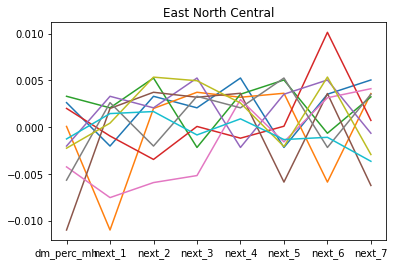

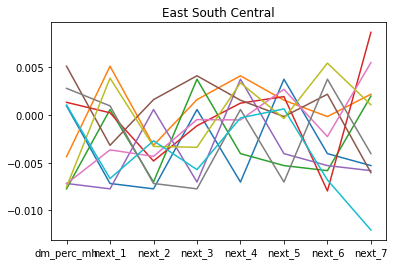

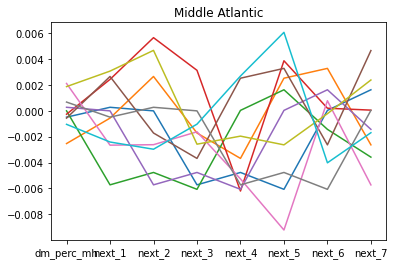

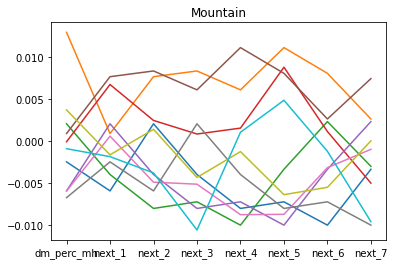

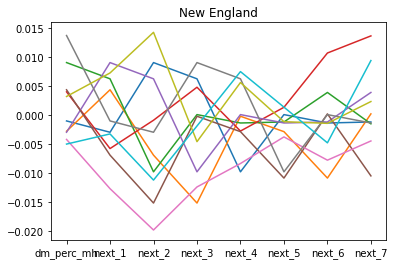

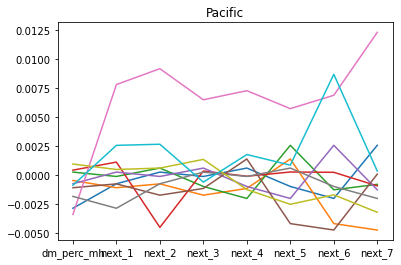

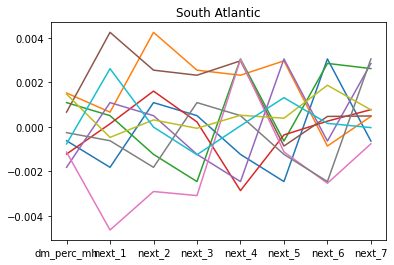

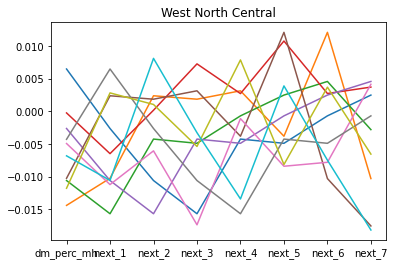

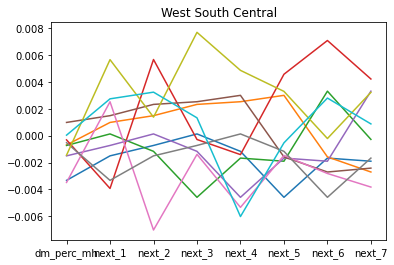

In [181]:
#plot x axis -, y-axis
cols = ['dm_perc_mh','next_1','next_2','next_3','next_4','next_5','next_6','next_7']
for name, group in result_grouped:
    filtered = group.sort_values(by = 'all_retweets_y', ascending = False)[:10]
    for index, day in filtered.iterrows():
        plt.plot(cols, day[cols], label = day['day'])
    plt.title(name)
#     plt.legend()
    plt.show()

# Scatter Plots


In [182]:
def graph_scatter(x, y, title, xlabel, ylabel):
    plt.scatter(x, y, alpha = .5)
    plt.title(title)
    plt.axhline(y=0, color='grey', linestyle='--')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
#     plt.show()

In [183]:
def get_all_days(og_df):
    all_days = pd.DataFrame(sp_share.index, columns = ['day'])
    all_days['date'] = pd.to_datetime(all_days['day'])
    og_df['date'] = pd.to_datetime(og_df['date'])
    df_all = all_days.merge(og_df, how = 'outer', on = 'date')
    return df_all.drop(columns = ['day'])

In [84]:
#number of police killings in a day in the census region vs share of mental health calls for that day
# vs share mental health calls for day + 1
# vs share mental health calls for day + 2
# vs share mental health calls for day + 3
'''
x: number of police killings on day x in census div
y: share mh calls on day x in census div
'''


'\nx: number of police killings on day x in census div\ny: share mh calls on day x in census div\n'

In [ ]:
'''
x: number of police killings on day x in census div
y: share mh calls on day x+1 in census div
'''

In [85]:
'''
x: number of police killings on day x in census div
y: share mh calls on day x+2 in census div
'''

'\nx: number of police killings on day x in census div\ny: share mh calls on day x+2 in census div\n'

In [86]:
'''
x: number of police killings on day x in census div
y: share mh calls on day x+3 in census div
'''

'\nx: number of police killings on day x in census div\ny: share mh calls on day x+3 in census div\n'

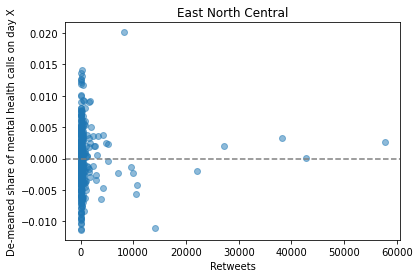

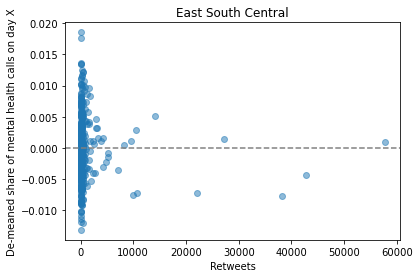

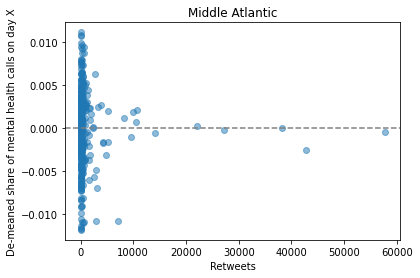

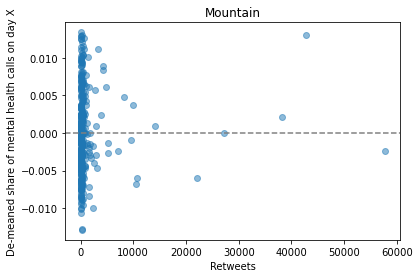

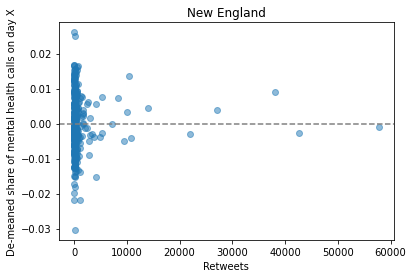

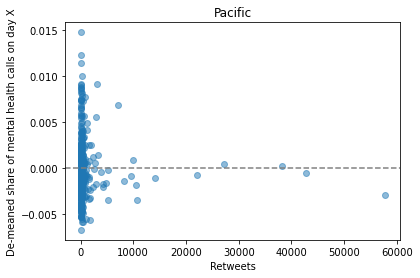

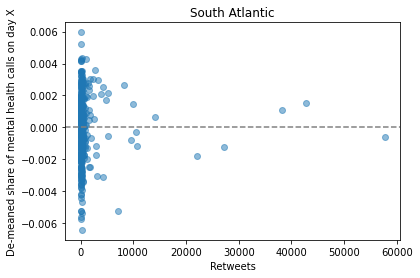

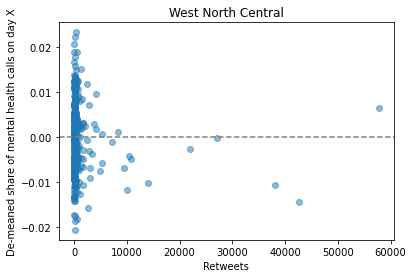

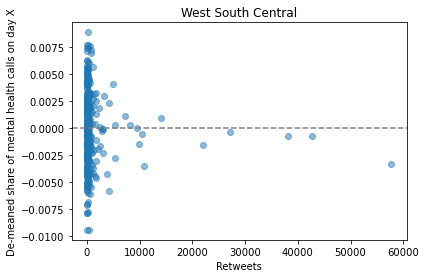

In [118]:
'''
x: number of retweets on day x
y: share demeaned mh calls on day x per census div
'''
cols = ['dm_perc_mh','next_1','next_2','next_3','next_4','next_5','next_6','next_7']
for name, group in result_grouped:
#     print(group)
    graph_scatter((group['all_retweets_y']), group['dm_perc_mh'], name, 'Retweets', 'De-meaned share of mental health calls on day X')
#     graph_scatter(np.log(group['all_retweets_y']), group['dm_perc_mh'], name, 'Log Retweets', 'De-meaned share of mental health calls on day X')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_of_dm_mh.png')
    plt.show()

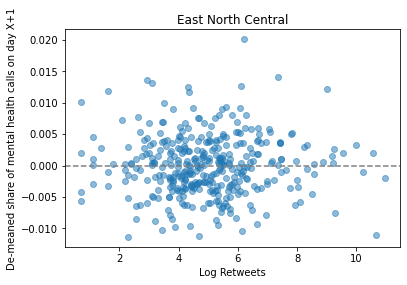

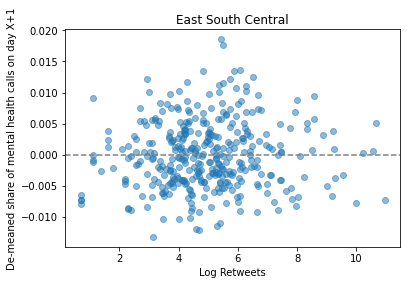

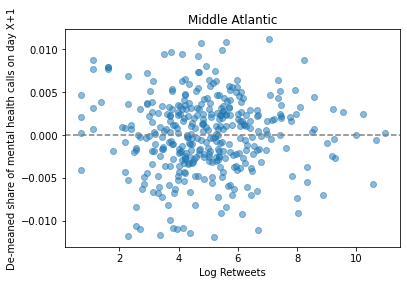

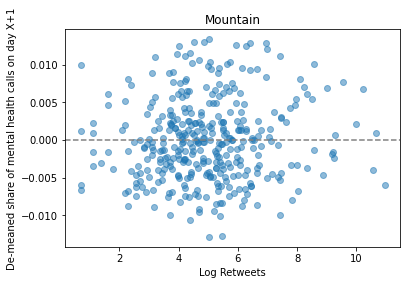

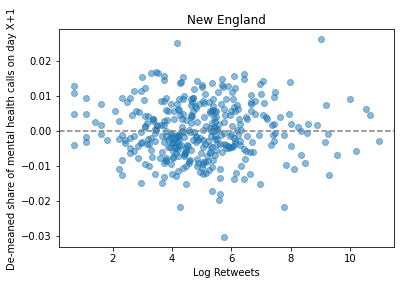

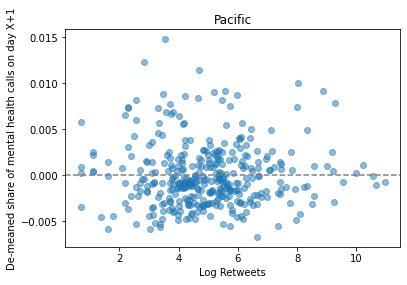

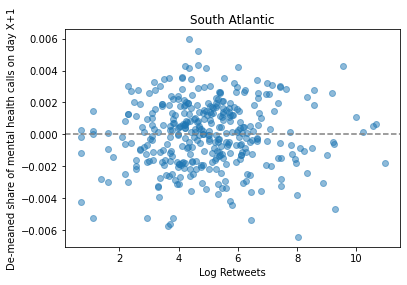

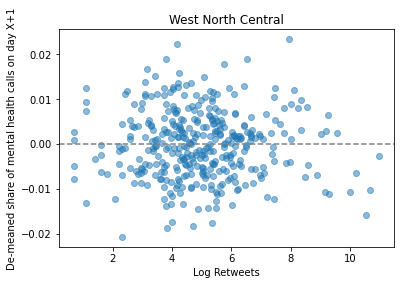

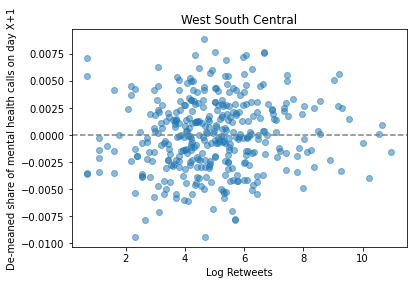

In [121]:
'''
x: number of retweets on day x
y: share demeaned mh calls on day x+1 per census div
'''
for name, group in result_grouped:
#     print(group)
    graph_scatter(np.log(group['all_retweets_y']), group['next_1'], name, 'Log Retweets', 'De-meaned share of mental health calls on day X+1')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+1_dm_mh_log_rt.png')
    plt.show()

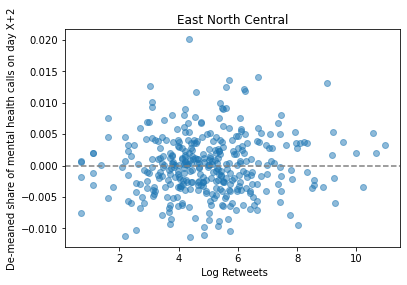

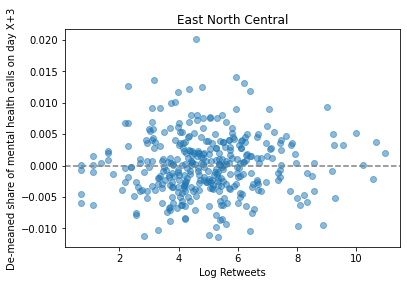

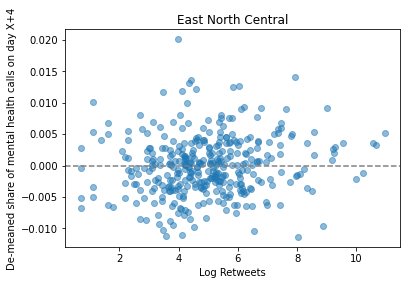

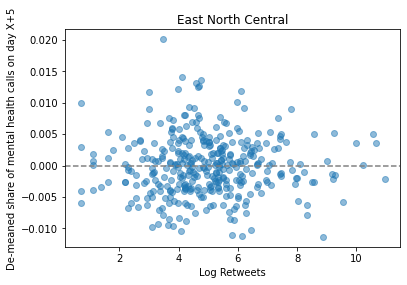

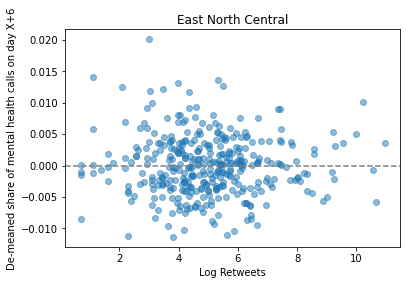

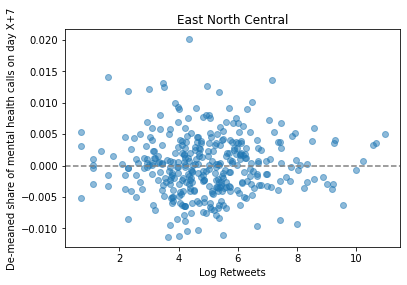

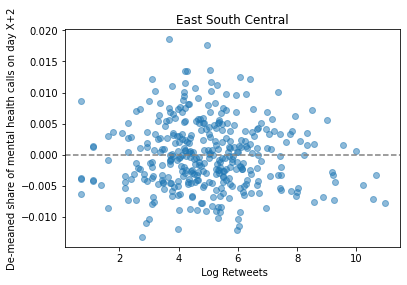

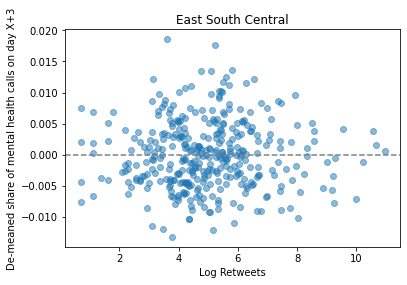

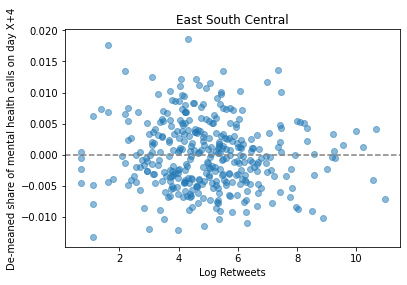

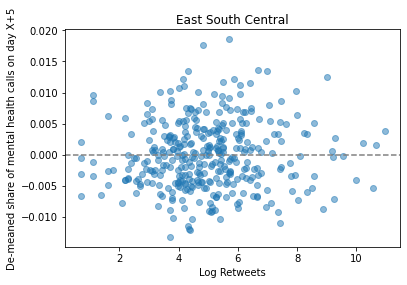

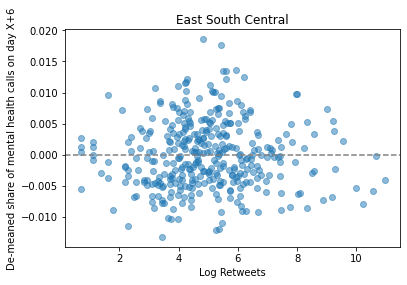

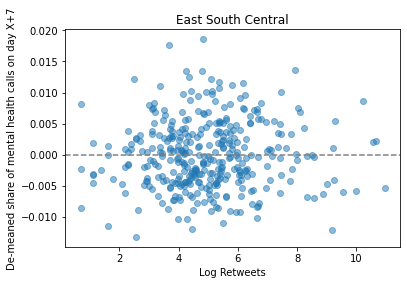

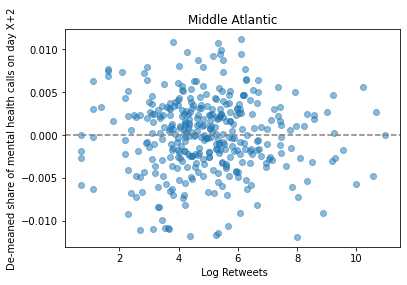

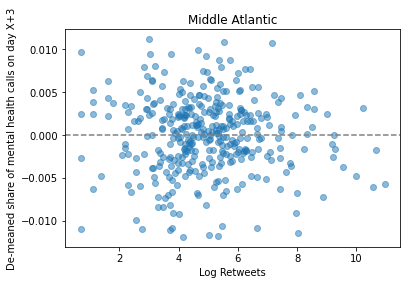

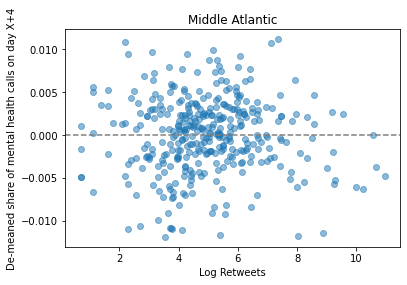

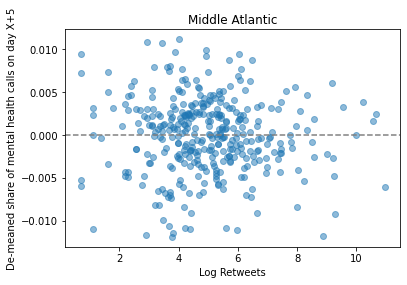

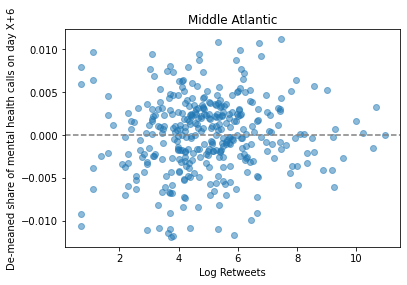

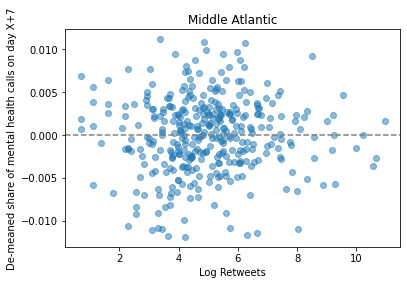

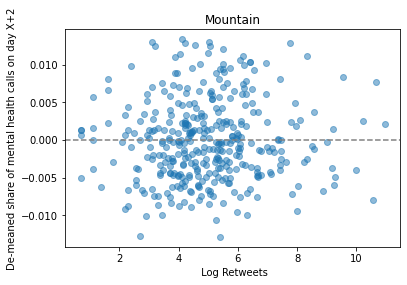

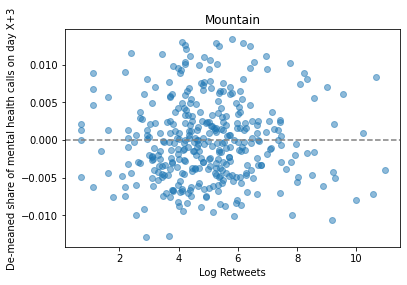

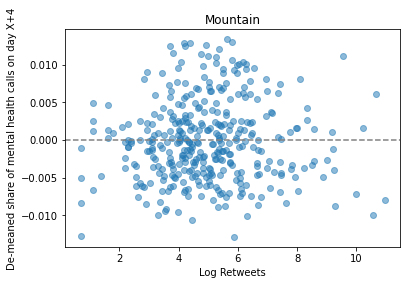

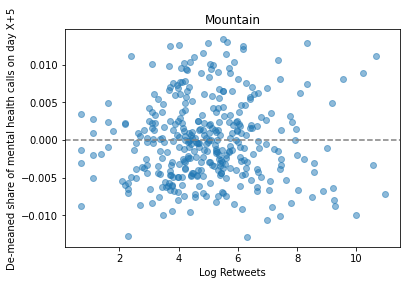

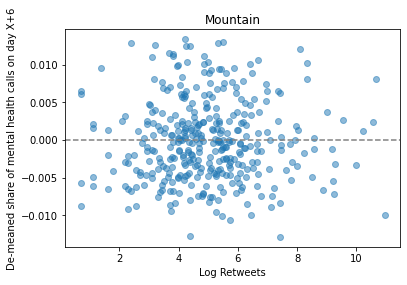

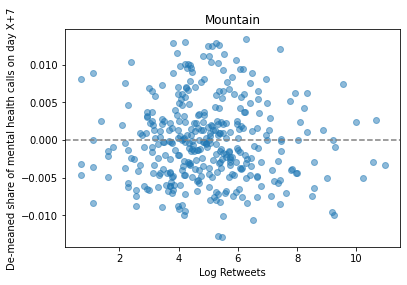

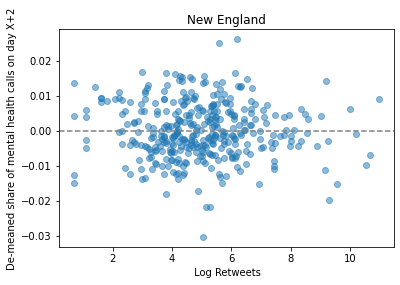

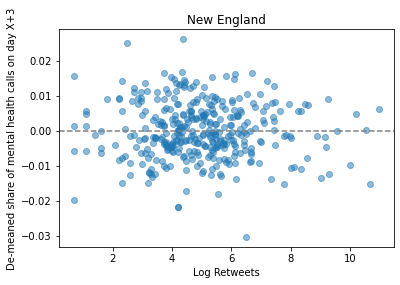

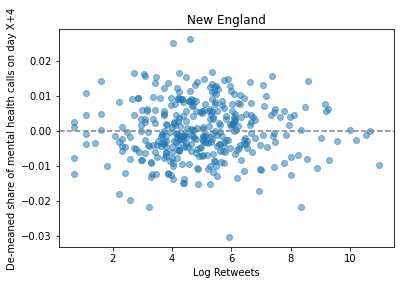

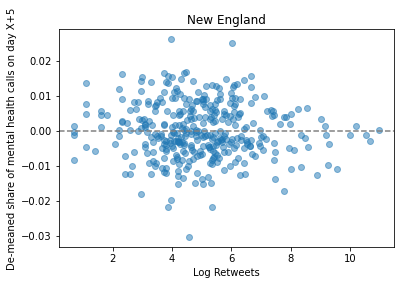

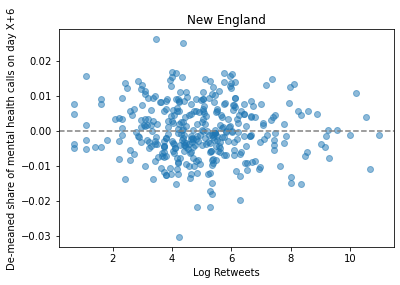

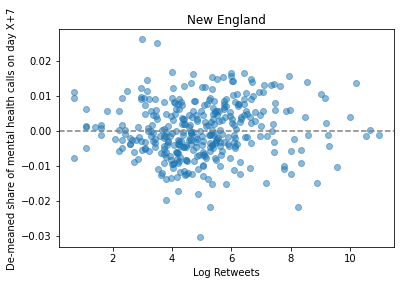

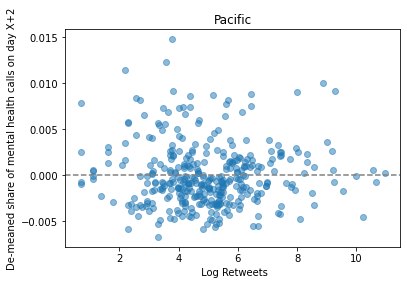

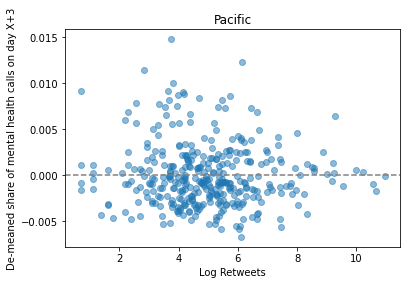

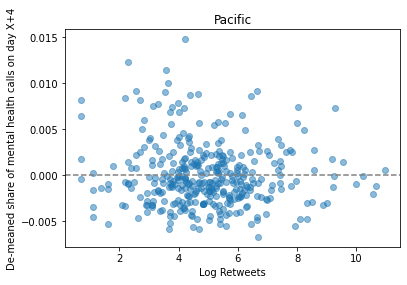

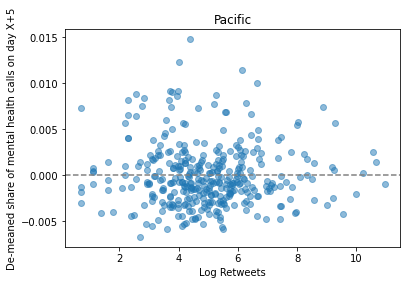

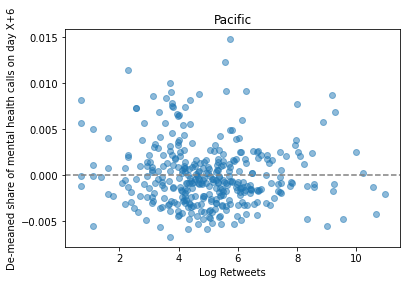

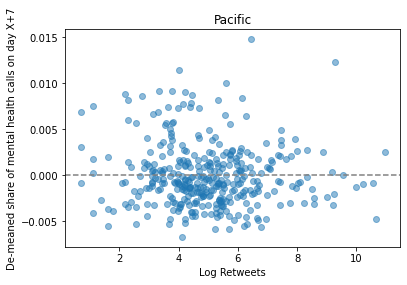

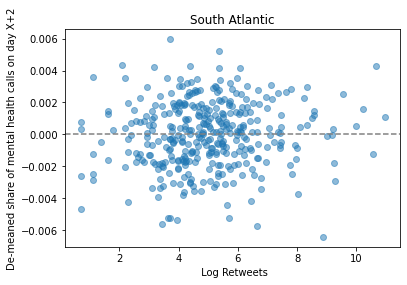

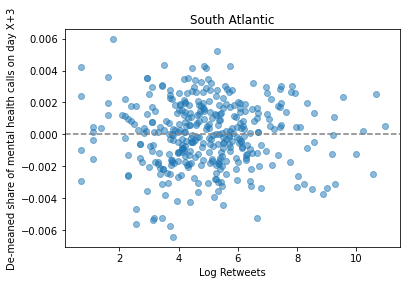

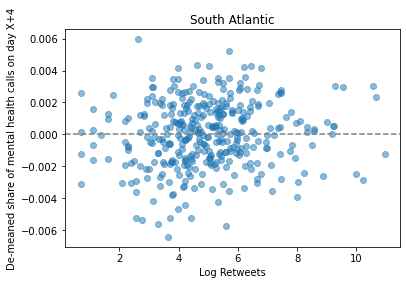

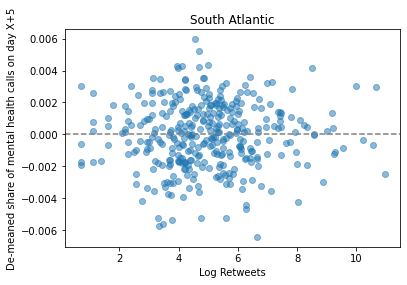

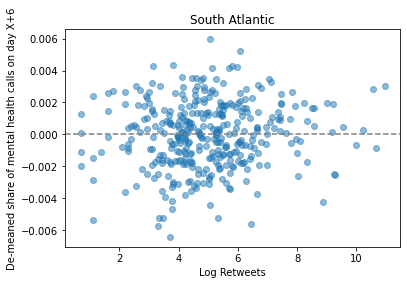

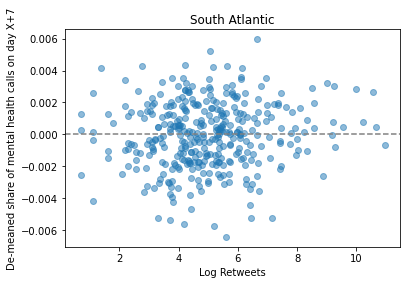

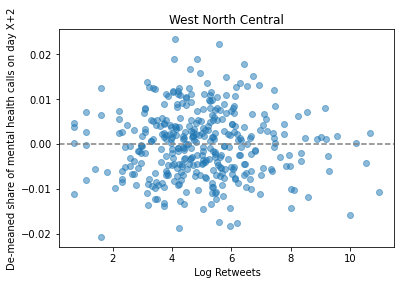

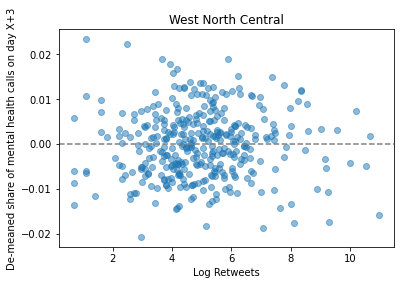

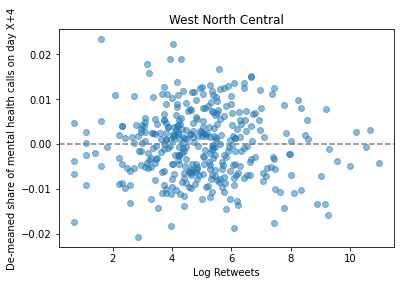

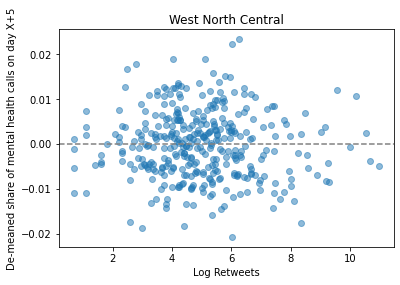

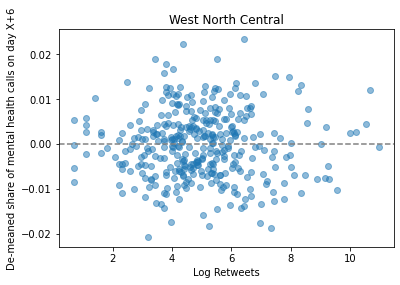

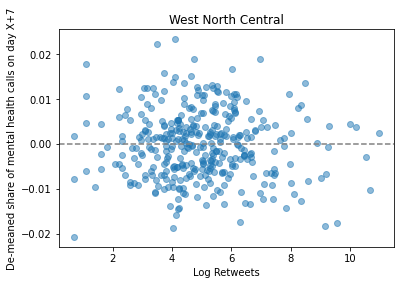

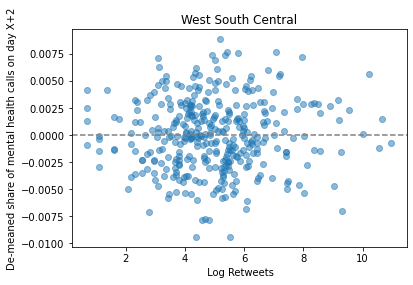

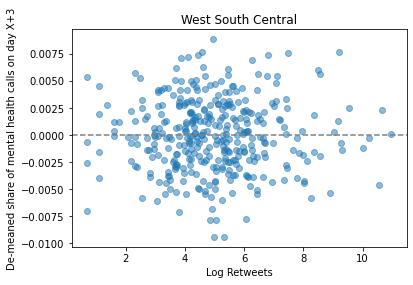

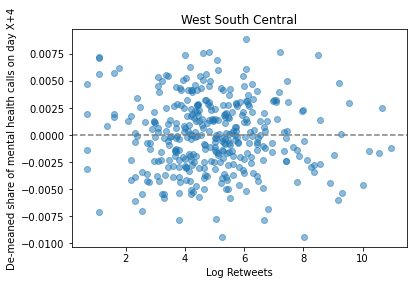

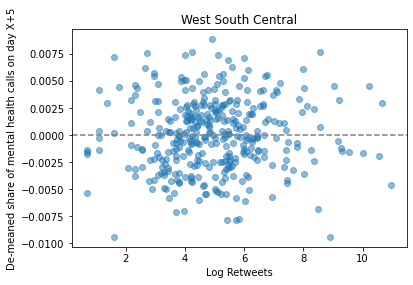

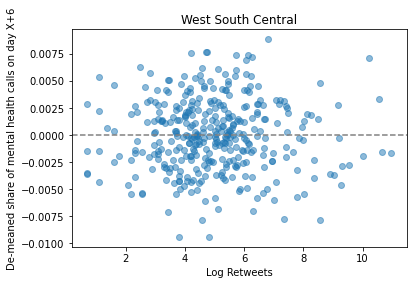

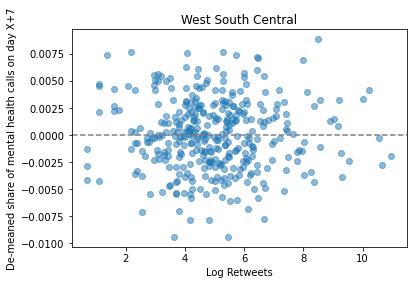

In [123]:
'''
x: number of retweets on day x
y: share demeaned mh calls on day x+2 per census div
'''
for name, group in result_grouped:
#     print(group)
    graph_scatter(np.log(group['all_retweets_y']), group['next_2'], name, ' Log Retweets', 'De-meaned share of mental health calls on day X+2')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+2_dm_mh_log_rt.png')
    plt.show()
    
    graph_scatter(np.log(group['all_retweets_y']), group['next_3'], name, 'Log Retweets', 'De-meaned share of mental health calls on day X+3')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+3_dm_mh_log_rt.png')
    plt.show()

    graph_scatter(np.log(group['all_retweets_y']), group['next_4'], name, 'Log Retweets', 'De-meaned share of mental health calls on day X+4')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+4_dm_mh_log_rt.png')
    plt.show()

    graph_scatter(np.log(group['all_retweets_y']), group['next_5'], name, 'Log Retweets', 'De-meaned share of mental health calls on day X+5')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+5_dm_mh_log_rt.png')
    plt.show()

    graph_scatter(np.log(group['all_retweets_y']), group['next_6'], name, 'Log Retweets', 'De-meaned share of mental health calls on day X+6')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+6_dm_mh_log_rt.png')
    plt.show()

    graph_scatter(np.log(group['all_retweets_y']), group['next_7'], name, 'Log Retweets', 'De-meaned share of mental health calls on day X+7')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+7_dm_mh_log_rt.png')
    plt.show()


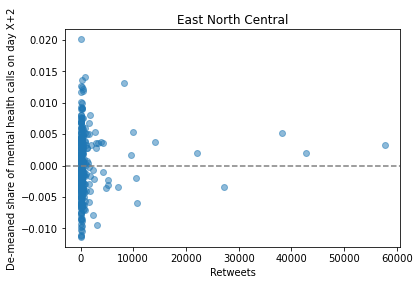

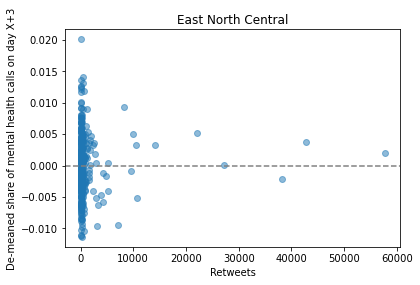

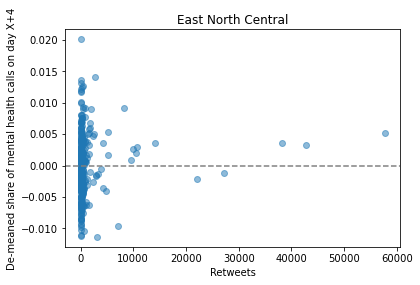

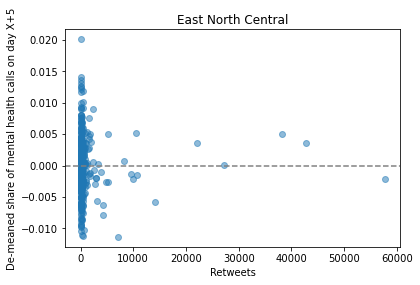

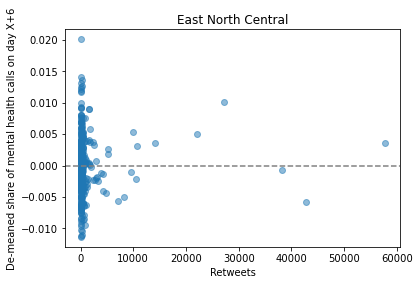

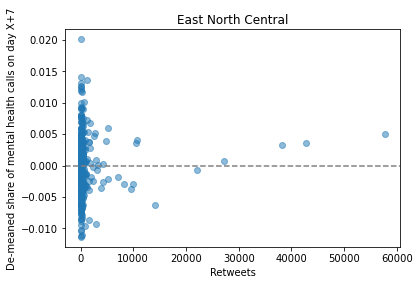

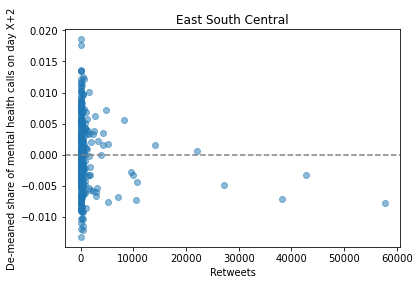

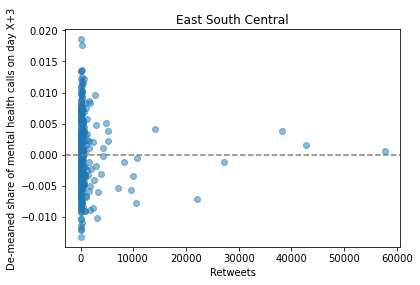

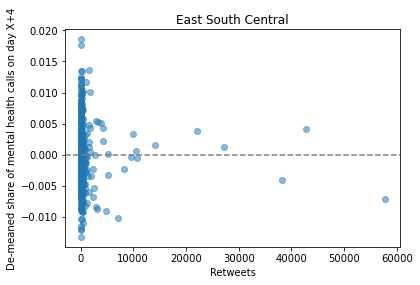

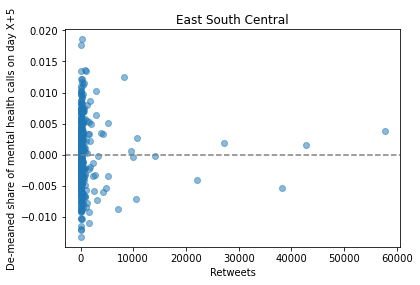

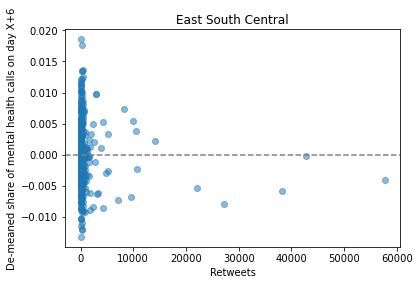

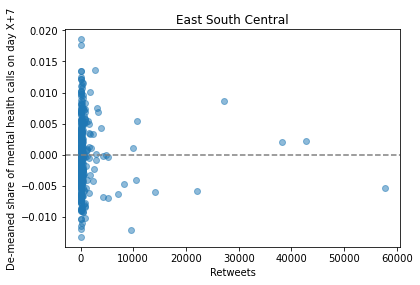

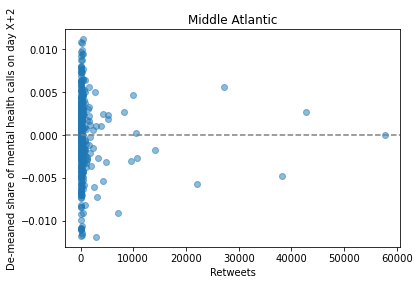

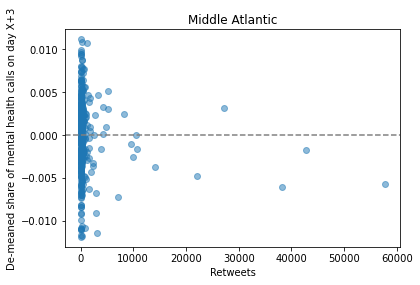

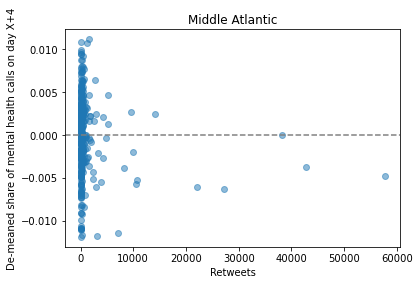

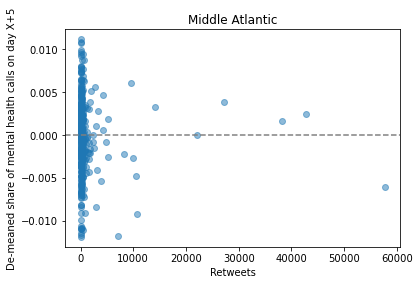

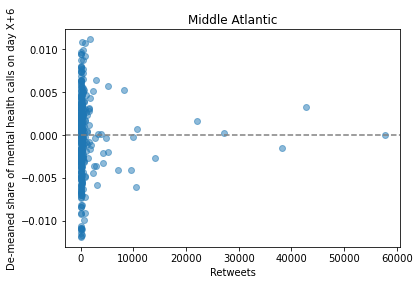

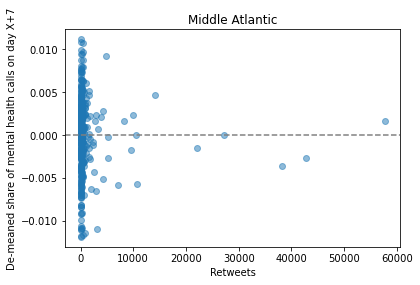

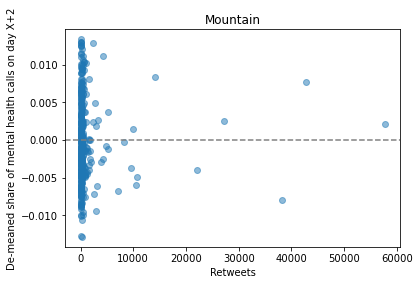

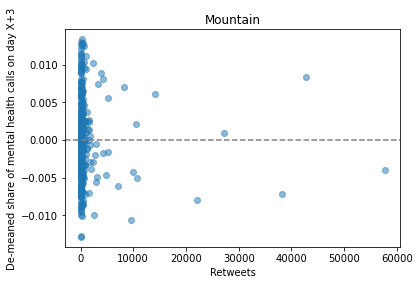

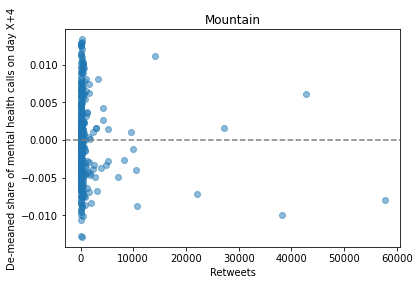

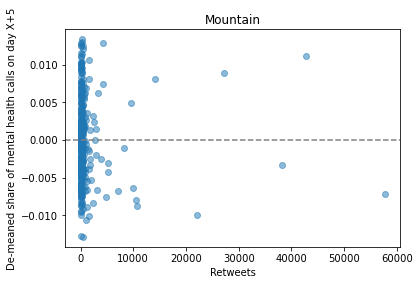

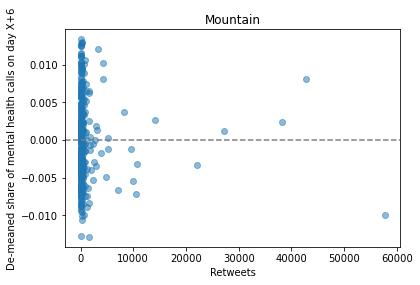

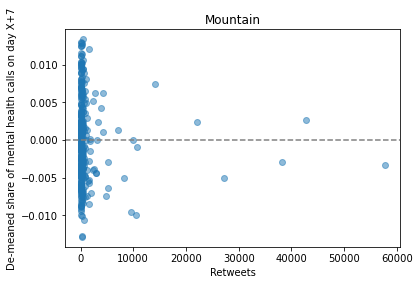

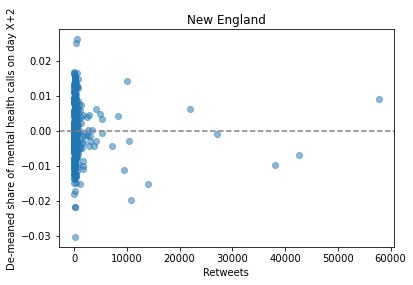

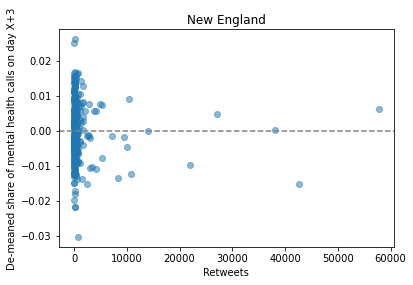

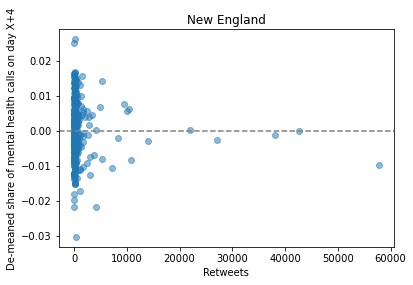

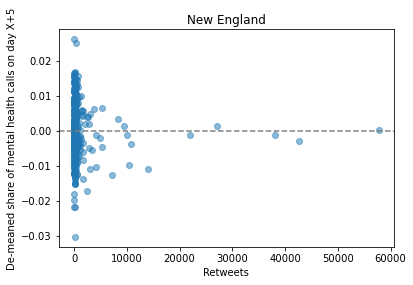

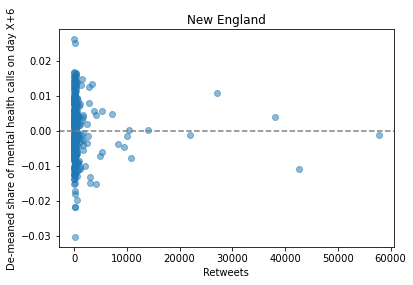

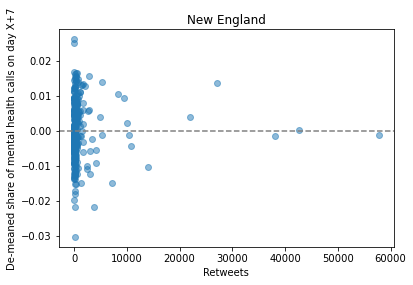

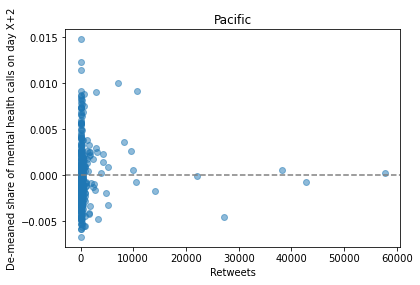

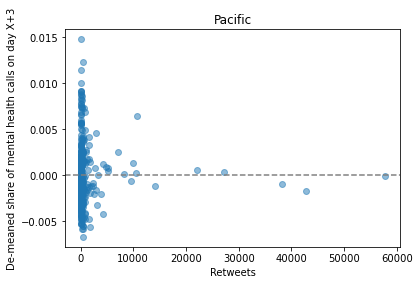

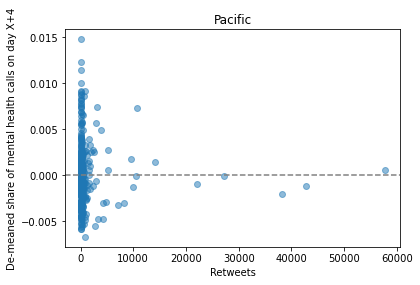

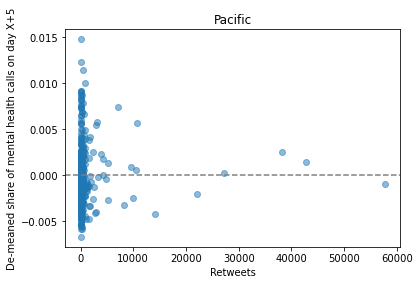

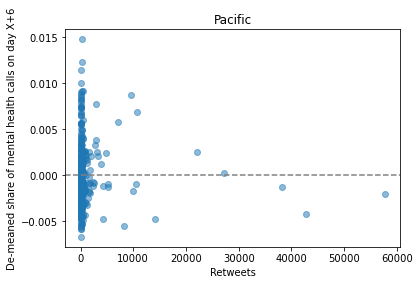

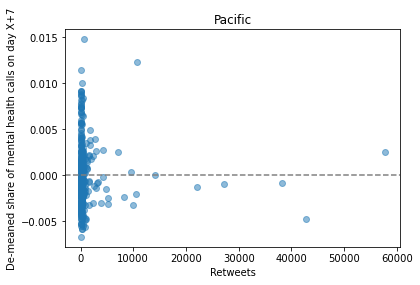

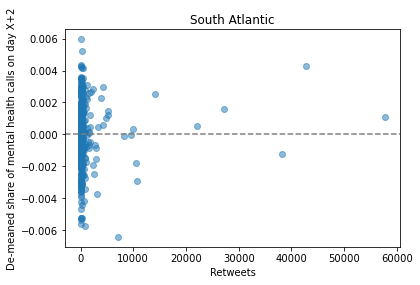

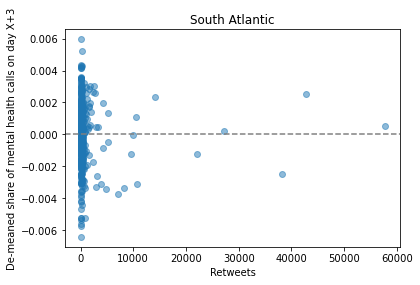

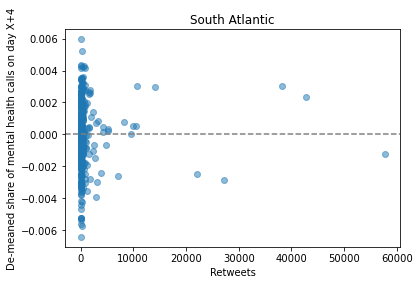

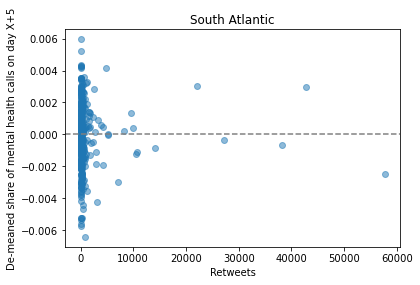

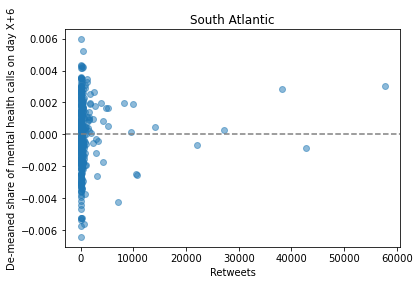

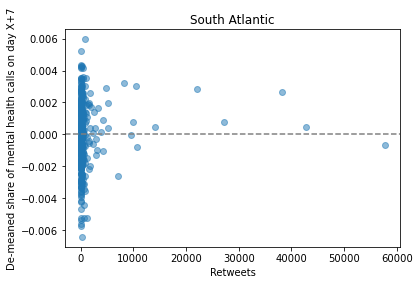

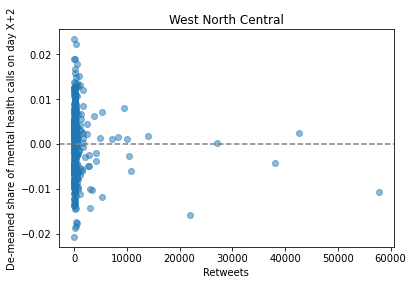

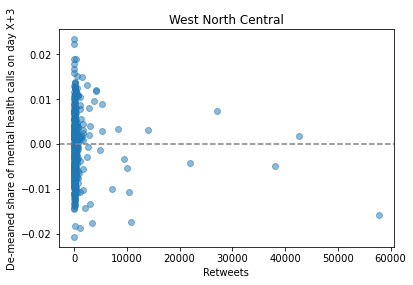

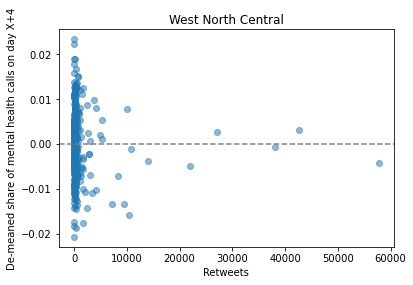

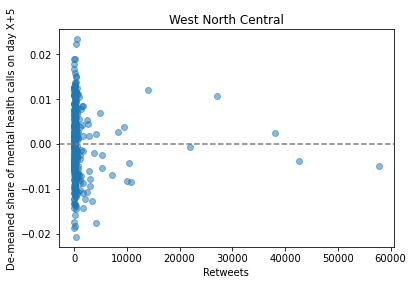

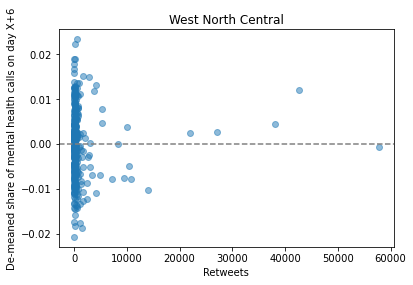

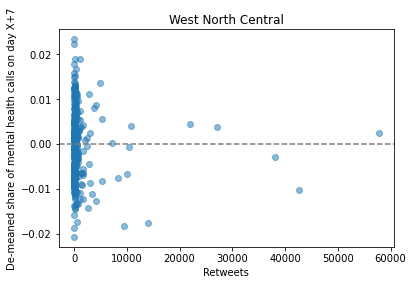

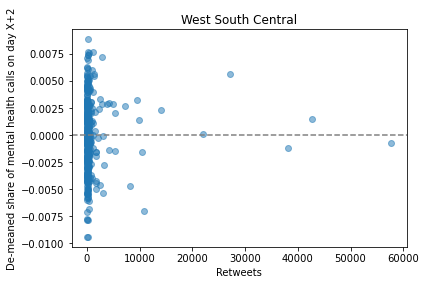

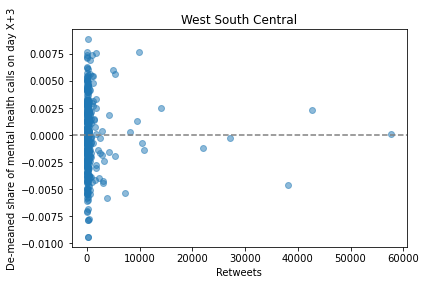

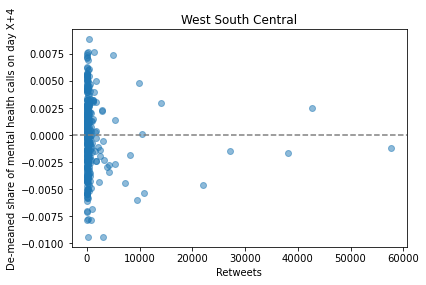

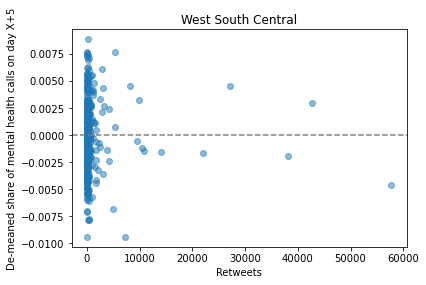

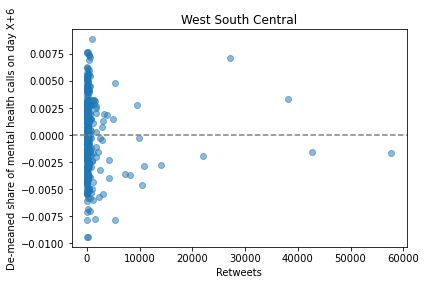

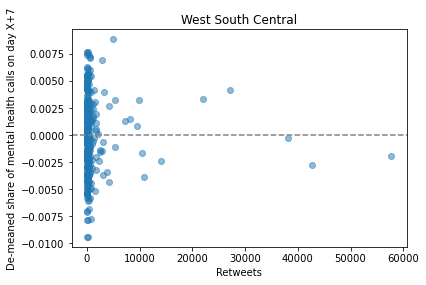

In [125]:
'''
x: number of retweets on day x
y: share demeaned mh calls on day x+2 per census div
'''
for name, group in result_grouped:
#     print(group)
    graph_scatter(group['all_retweets_y'], group['next_2'], name, 'Retweets', 'De-meaned share of mental health calls on day X+2')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+2_dm_mh.png')
    plt.show()
    
    graph_scatter(group['all_retweets_y'], group['next_3'], name, 'Retweets', 'De-meaned share of mental health calls on day X+3')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+3_dm_mh.png')
    plt.show()

    graph_scatter(group['all_retweets_y'], group['next_4'], name, 'Retweets', 'De-meaned share of mental health calls on day X+4')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+4_dm_mh.png')
    plt.show()

    graph_scatter(group['all_retweets_y'], group['next_5'], name, 'Retweets', 'De-meaned share of mental health calls on day X+5')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+5_dm_mh.png')
    plt.show()

    graph_scatter(group['all_retweets_y'], group['next_6'], name, 'Retweets', 'De-meaned share of mental health calls on day X+6')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+6_dm_mh.png')
    plt.show()

    graph_scatter(group['all_retweets_y'], group['next_7'], name, 'Retweets', 'De-meaned share of mental health calls on day X+7')
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210721_scatter_plots/"+name+'_day_+7_dm_mh.png')
    plt.show()


# Box and Whisker Plots

In [195]:
#define a function to do the box and whisker plot
def box_and_whisk(data, title, col_labels):
    no_na = data.dropna(axis = 0)
    plt.boxplot(no_na, labels = col_labels)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210725_box_plots/bottom_20perc_box_plot_next_seven_days_"+title+'.png')
    plt.show()

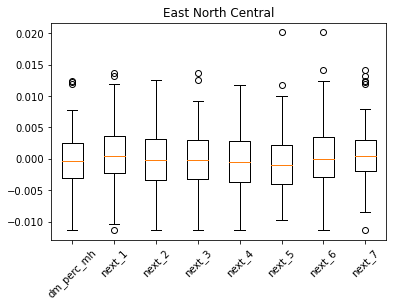

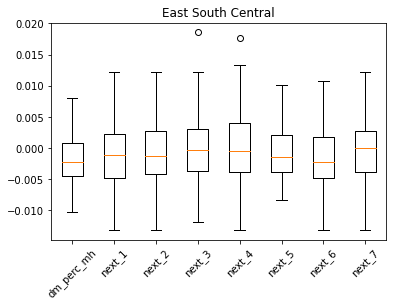

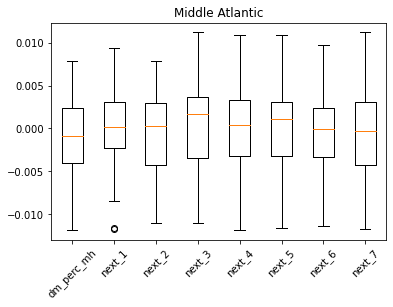

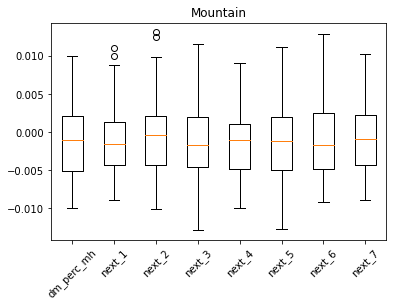

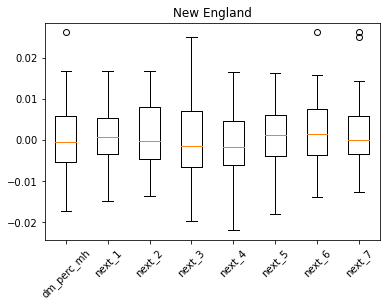

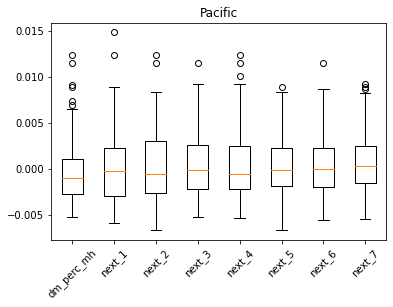

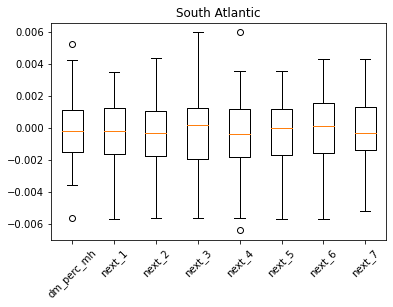

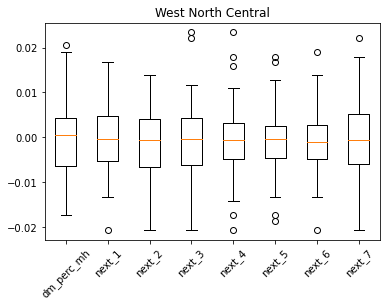

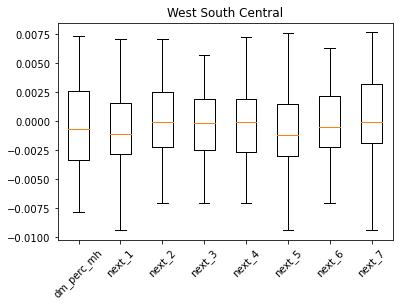

In [196]:
#get the top quintile
cols = ['dm_perc_mh','next_1','next_2','next_3','next_4','next_5','next_6','next_7']
for name, group in result_grouped:
    filtered = group[group['all_retweets_x'] == '0-20']
    box_and_whisk(filtered[cols], name, cols)
#     plt.legend()
#     plt.show()

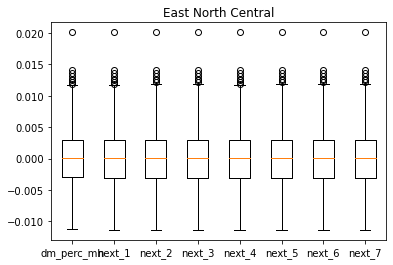

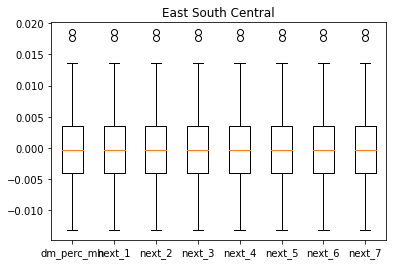

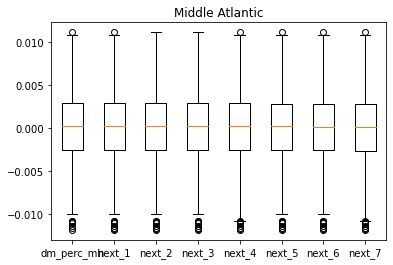

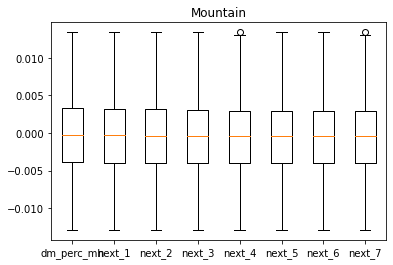

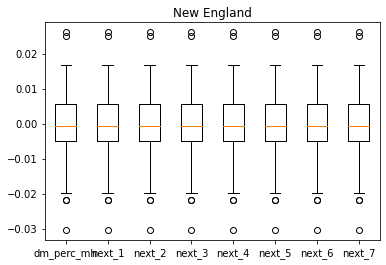

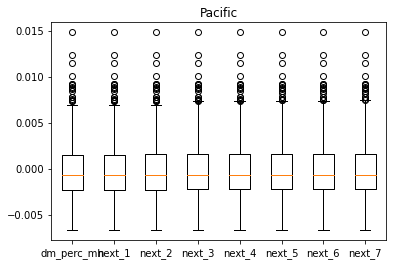

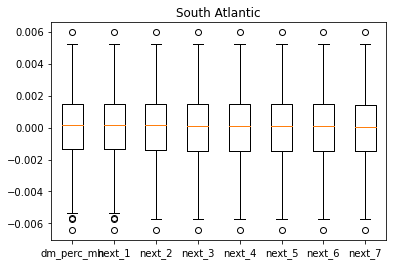

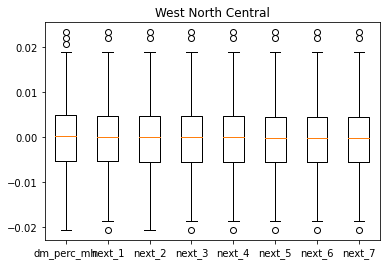

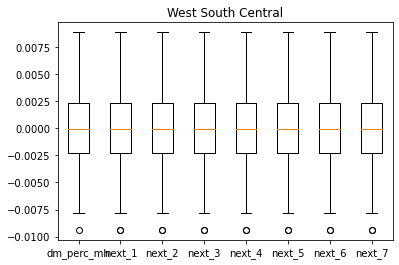

In [139]:
for name, group in result_grouped:
    box_and_whisk(group[cols], name, cols)

In [197]:
urban_private_dd

,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh
0,2019-01-01,East North Central,3042,138,0.045365,Tuesday,-0.001239
1,2019-01-01,East South Central,1397,47,0.033644,Tuesday,-0.001614
2,2019-01-01,Middle Atlantic,3482,138,0.039632,Tuesday,-0.001653
3,2019-01-01,Mountain,2489,102,0.040980,Tuesday,0.003609
4,2019-01-01,New England,926,68,0.073434,Tuesday,0.016626
...,...,...,...,...,...,...,...
3280,2019-12-31,New England,1331,69,0.051841,Tuesday,-0.004967
3281,2019-12-31,Pacific,1754,52,0.029647,Tuesday,0.008184
3282,2019-12-31,South Atlantic,8147,204,0.025040,Tuesday,-0.001988
3283,2019-12-31,West North Central,1373,53,0.038602,Tuesday,-0.005262


In [198]:
w_tweets = urban_private_dd.merge(how = 'left', right = tweets_by_day, on = 'day')

In [199]:
w_tweets

,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,tweet_count,retweet_count,quote_count,all_retweets
0,2019-01-01,East North Central,3042,138,0.045365,Tuesday,-0.001239,16,21,1,22
1,2019-01-01,East South Central,1397,47,0.033644,Tuesday,-0.001614,16,21,1,22
2,2019-01-01,Middle Atlantic,3482,138,0.039632,Tuesday,-0.001653,16,21,1,22
3,2019-01-01,Mountain,2489,102,0.040980,Tuesday,0.003609,16,21,1,22
4,2019-01-01,New England,926,68,0.073434,Tuesday,0.016626,16,21,1,22
...,...,...,...,...,...,...,...,...,...,...,...
3280,2019-12-31,New England,1331,69,0.051841,Tuesday,-0.004967,31,67,15,82
3281,2019-12-31,Pacific,1754,52,0.029647,Tuesday,0.008184,31,67,15,82
3282,2019-12-31,South Atlantic,8147,204,0.025040,Tuesday,-0.001988,31,67,15,82
3283,2019-12-31,West North Central,1373,53,0.038602,Tuesday,-0.005262,31,67,15,82


In [241]:
w_tweets[w_tweets['all_retweets'] == 0]

,day,CensusDivision,all_calls,mh_calls,perc_mh,weekday,dm_perc_mh,mh_quant,tweet_count,retweet_count,quote_count,all_retweets


<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


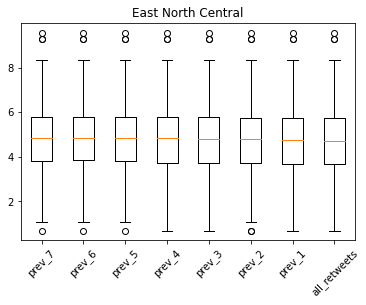

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


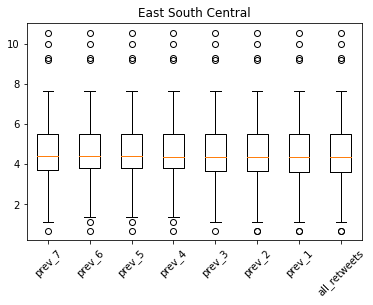

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


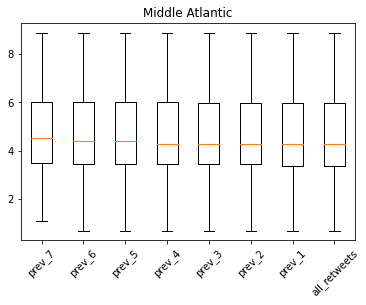

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


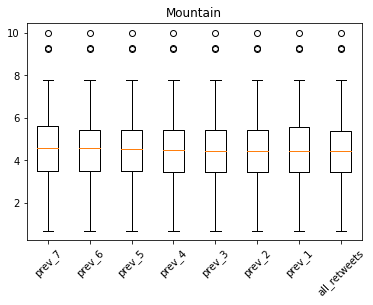

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


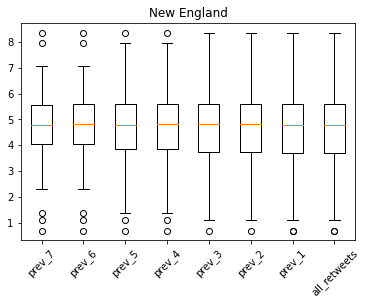

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


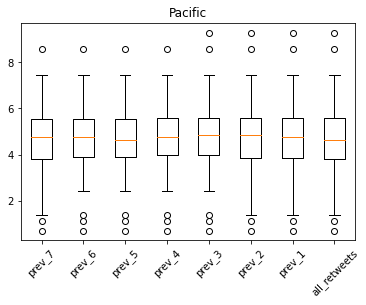

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


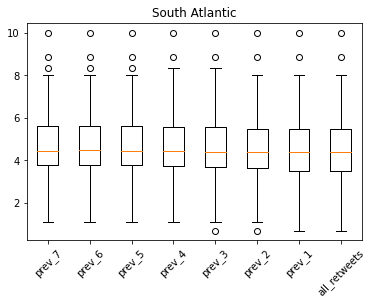

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


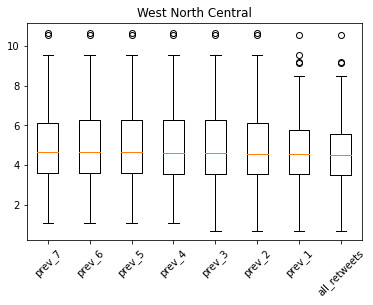

<ipython-input-251-b18c2b92b1c6>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))


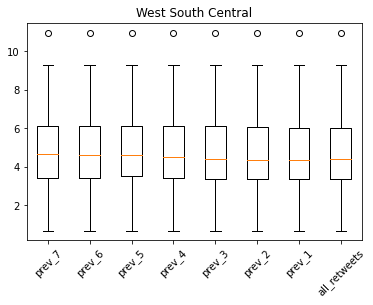

In [251]:
#lets look at highest mental health days and twitter averages
#lets now split the tweet days into quantiles
by_div = urban_private_dd.groupby(['CensusDivision'])
for name, group in by_div:
    labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
    q_cut_mh_no_labels = pd.DataFrame(pd.qcut(group['dm_perc_mh'], 5))
    q_cut_mh = pd.DataFrame(pd.qcut(group['dm_perc_mh'], 5, labels)).rename(columns = {'dm_perc_mh':'mh_quant'})
#     print(q_cut_mh)
    w_cut = group.join(q_cut_mh)
#     print(w_cut)
#     print(group)
    w_cut['day'] = pd.to_datetime(w_cut['day'])
    
    w_tweets = w_cut.merge(right = tweets_by_day, how = 'left', on = 'day')
    
#     print(w_tweets)
    
    
    top_mh = w_tweets[w_tweets['mh_quant'] == '80-100']
    bot_mh = w_tweets[w_tweets['mh_quant'] == '0-20']
    
    result = pd.DataFrame(columns = w_day_of.columns)
    
    for i in range(1,8):
        bot_mh['prev_'+str(i)] = np.log(bot_mh['all_retweets'].shift(i))
        result = pd.concat([result, bot_mh])

    col_labels = ['all_retweets', 'prev_1', 'prev_2', 'prev_3', 'prev_4', 'prev_5', 'prev_6', 'prev_7']
    no_na = result[col_labels].iloc[:, ::-1].dropna(axis = 0)
#     print(no_na[no_na['all_retweets'] == 0])
#     print(no_na.dtypes)
    no_na['all_retweets'] = np.log(no_na['all_retweets'].astype(float))
#     print(no_na)
    plt.boxplot(no_na, labels = no_na.columns)
    plt.title(name)
    plt.xticks(rotation=45)
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210725_box_plots/bottom_20_mh_box_plot_prev_week_LOG_tweets_"+name+'.png')
    plt.show()
    

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


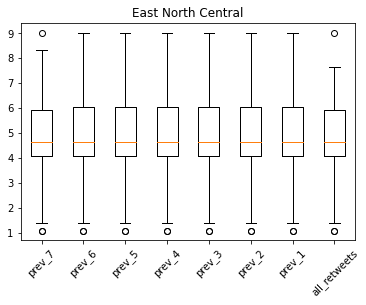

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


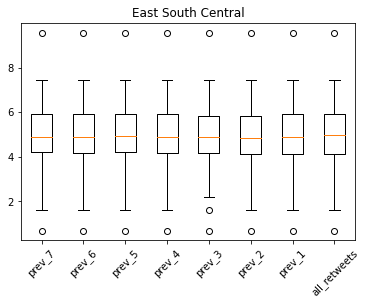

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


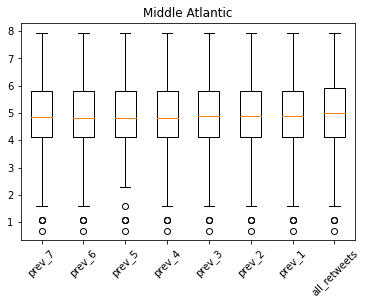

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


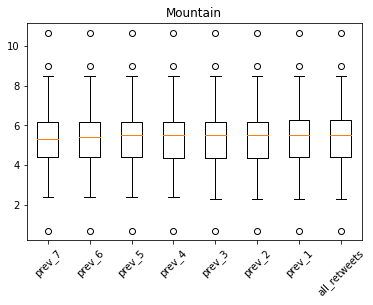

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


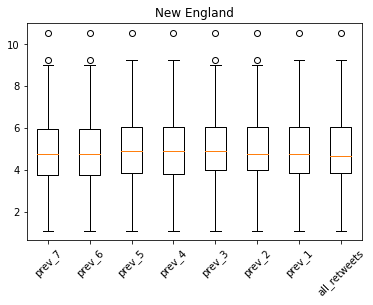

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


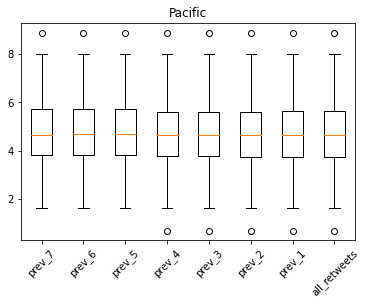

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


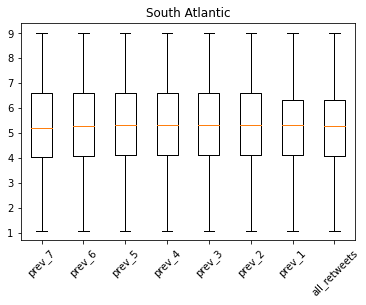

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


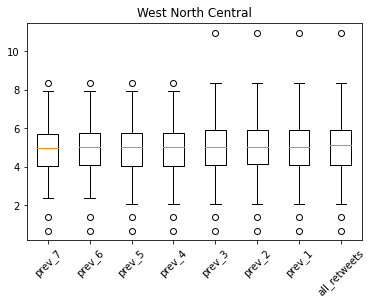

<ipython-input-252-a771f442d3f8>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))


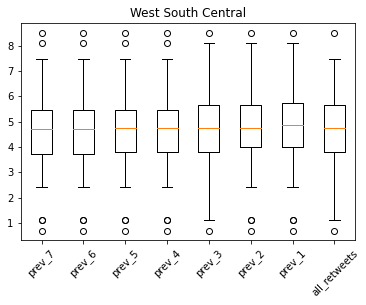

In [252]:
#lets look at highest mental health days and twitter averages
#lets now split the tweet days into quantiles
by_div = urban_private_dd.groupby(['CensusDivision'])
for name, group in by_div:
    labels = ['0-20', '20-40', '40-60', '60-80', '80-100']
    q_cut_mh_no_labels = pd.DataFrame(pd.qcut(group['dm_perc_mh'], 5))
    q_cut_mh = pd.DataFrame(pd.qcut(group['dm_perc_mh'], 5, labels)).rename(columns = {'dm_perc_mh':'mh_quant'})
#     print(q_cut_mh)
    w_cut = group.join(q_cut_mh)
#     print(w_cut)
#     print(group)
    w_cut['day'] = pd.to_datetime(w_cut['day'])
    
    w_tweets = w_cut.merge(right = tweets_by_day, how = 'left', on = 'day')
    
#     print(w_tweets)
    
    
    top_mh = w_tweets[w_tweets['mh_quant'] == '80-100']
    bot_mh = w_tweets[w_tweets['mh_quant'] == '0-20']
    
    result = pd.DataFrame(columns = w_day_of.columns)
    
    for i in range(1,8):
        top_mh['prev_'+str(i)] = np.log(top_mh['all_retweets'].shift(i))
        result = pd.concat([result, top_mh])

    col_labels = ['all_retweets', 'prev_1', 'prev_2', 'prev_3', 'prev_4', 'prev_5', 'prev_6', 'prev_7']
    no_na = result[col_labels].iloc[:, ::-1].dropna(axis = 0)
    no_na['all_retweets'] = np.log(no_na['all_retweets'].astype(float))
#     print(no_na)
    plt.boxplot(no_na, labels = no_na.columns)
    plt.title(name)
    plt.xticks(rotation=45)
    plt.savefig("C:/Users/meita/Dropbox (MIT)/NEMSIS Data/Analysis/Output/210725_box_plots/top_20_mh_box_plot_prev_week_LOG_tweets_"+name+'.png')
    plt.show()
    
    
    #lets get the quantiles of the mental health related 911 calls for each division
# #     results = pd.DataFrame(index = labels)
    
#     for name, group in div_grouped_private:
#         #join with the tweets information
#         w_quant = group.merge(q_cut_tweets, on = 'day')
#         interm  = pd.DataFrame(w_quant.groupby(['all_retweets']).mean()['dm_perc_mh']).rename(columns = {'dm_perc_mh':name})
#         results = results.merge(interm, right_index = True, left_index = True)
